
# D-PARC Model Demonstration Notebook

## Unified notebook for demonstrating D-PARC models across three physics datasets:
### - Burgers Equation
### - Navier-Stokes
### - Energetic Materials (HMX)

Each dataset has three trained models: D-PARC, PARC-v2, and Large PARC-v2.
"""


In [3]:
import os
import sys
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
import csv
from torch.utils.data import DataLoader
import gc
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from pathlib import Path

# Add project root to system path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

# Import PARCTorch components
from PARCtorch.PARCv2 import PARCv2
from PARCtorch.utilities.unet_deform import UNet
from PARCtorch.data.dataset import GenericPhysicsDataset, custom_collate_fn
from PARCtorch.differentiator.differentiator import ADRDifferentiator as Differentiator
from PARCtorch.differentiator.finitedifference import FiniteDifference
from PARCtorch.integrator.integrator import Integrator
from PARCtorch.integrator.heun import Heun
from PARCtorch.integrator.rk4 import RK4

# Device configuration
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✓ All libraries imported successfully")
print(f"✓ Using device: {DEVICE}")


✓ All libraries imported successfully
✓ Using device: cuda


In [7]:
"""
All dataset configurations in one place.
Select which dataset to use by setting SELECTED_DATASET below.
"""

DATASET_CONFIGS = {
    'burgers': {
        'name': 'Burgers Equation',
        'checkpoints': {
            'dparc': '/home/jtb3sud/weights_dparc/burgers/DPARC.pth',
            'parc': '/home/jtb3sud/weights_dparc/burgers/PARCv2.pth',
            'large': '/home/jtb3sud/weights_dparc/burgers/PARCv2L.pth',
        },
        'data_dir': '/project/vil_baek/data/physics/PARCTorch/Burgers/test',
        'min_max_path': '../data/b_min_max.json',
        'output_dir': '../results/comparison_burgers',
        'future_steps': 100,
        'batch_size': 28,
        'sample_id': 121,
        'viz_timesteps': [0, 15, 30, 45, 60],
        'time_per_step': 0.02,
        'integrator': 'heun',
        'n_fe_features': 64,
        'model_params': {
            'dparc': {
                'block_dimensions': [64, 128, 256],
                'input_channels': 3,
                'up_block_use_concat': [False, True],
                'skip_connection_indices': [0],
            },
            'parc': {
                'block_dimensions': [64, 128, 256],
                'input_channels': 3,
                'up_block_use_concat': [False, True],
                'skip_connection_indices': [0],
            },
            'large': {
                'block_dimensions': [64, 128, 256, 512, 1024],
                'input_channels': 3,
                'up_block_use_concat': [False, True, False, True],
                'skip_connection_indices': [2, 0],
            },
        },
        'differentiator_params': {
            'n_params': 1,  # Reynolds number
            'input_channels': [1, 2],  # u, v
            'output_channels': [1, 2],  # u, v
            'padding_mode': 'constant',
            'requires_grad': False,
        },
        'integrator_params': {
            'requires_grad': True,
            'integration_channels': [],
            'ddi_list': [None, None, None],
        },
        'erf_config': {
        'sample_id': 0,  # Specific sample for ERF analysis
        'output_point': (53, 53),  # Representative shock point
        'analyze_timestep': 47,
        'channel_to_visualize': 1,  # Velocity U
        'channel_names': {1: 'Velocity U', 2: 'Velocity V'},
        'channel_cmaps': {1: 'seismic', 2: 'seismic'},
        'vmin_viz': None,  # Auto-scale
        'vmax_viz': None,  # Auto-scale
        # Multi-point analysis
        'region1_points': [(53, 53), (49, 53), (55, 45)],  # High gradient (shock)
        'region2_points': [(50, 10), (9, 9), (7, 51)],     # Low gradient (smooth)
        'region1_name': 'High Gradient',
        'region2_name': 'Low Gradient',
        'parcv2_trf_area': 324,  # Theoretical receptive field for Burgers
        'test_thresholds': [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10],
        },
        'channel_info': {
            'viz': {
                'Velocity U': {'idx': 1, 'cmap': 'seismic', 'label': 'm/s'},
                'Velocity V': {'idx': 2, 'cmap': 'seismic', 'label': 'm/s'},
            },
            'metrics': {
                'Velocity Magnitude': {'idx': (1, 2), 'unit': 'm/s'},
            }
        },
    },
    
    'navier_stokes': {
        'name': 'Navier-Stokes',
        'checkpoints': {
            'dparc': '/home/jtb3sud/weights_dparc/ns/DPARC.pth',
            'parc': '/home/jtb3sud/weights_dparc/ns/PARCv2.pth',
            'large': '/home/jtb3sud/weights_dparc/ns/PARCv2L.pth',
        },
        'data_dir': '/project/vil_baek/data/physics/PARCTorch/NavierStokes/jack_train',
        'min_max_path': '../data/ns_min_max.json',
        'output_dir': '../results/comparison_ns',
        'future_steps': 38,
        'batch_size': 12,
        'sample_id': 8,
        'viz_timesteps': [0, 7, 14, 21, 28],
        'time_per_step': 0.052631578,
        'integrator': 'heun',
        'n_fe_features': 128,
        'model_params': {
            'dparc': {
                'block_dimensions': [64, 128, 256, 512, 1024],
                'input_channels': 4,
                'up_block_use_concat': [False, True, False, True],
                'skip_connection_indices': [2, 0],
            },
            'parc': {
                'block_dimensions': [64, 128, 256, 512, 1024],
                'input_channels': 4,
                'up_block_use_concat': [False, True, False, True],
                'skip_connection_indices': [2, 0],
            },
            'large': {
                'block_dimensions': [64, 128, 256, 512, 1024, 2048, 4096],
                'input_channels': 4,
                'up_block_use_concat': [False, True, False, True, False, False],
                'skip_connection_indices': [4, 2],
            },
        },
        'differentiator_params': {
            'n_params': 2,
            'input_channels': [2, 3],  # U, V
            'output_channels': [2, 3],  # U, V
            'padding_mode': 'constant',
            'requires_grad': True,
        },
        'integrator_params': {
            'requires_grad': True,
            'integration_channels': [(0, 2, 3, 1)],
            'ddi_list': [None, None, None, None],
        },
        'erf_config': {
        'sample_id': 11,  # Specific sample for ERF analysis
        'output_point': (87, 80),  # Representative high strain point
        'analyze_timestep': 24,
        'channel_to_visualize': 2,  # Velocity U
        'channel_names': {1: 'Pressure P', 2: 'Velocity U', 3: 'Velocity V'},
        'channel_cmaps': {1: 'viridis', 2: 'seismic', 3: 'seismic'},
        'vmin_viz': None,  # Auto-scale
        'vmax_viz': None,  # Auto-scale
        # Multi-point analysis
        'region1_points': [(87, 80), (45, 80), (50, 80)],  # High strain
        'region2_points': [(105, 202), (10, 150), (55, 5)],  # Low strain
        'region1_name': 'High Strain',
        'region2_name': 'Low Strain',
        'parcv2_trf_area': 6084,
        'test_thresholds': [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10],
        },
        'channel_info': {
            'viz': {
                'Pressure P': {'idx': 1, 'cmap': 'viridis', 'label': 'GPa'},
                'Velocity U': {'idx': 2, 'cmap': 'seismic', 'label': 'm/s'},
                'Velocity V': {'idx': 3, 'cmap': 'seismic', 'label': 'm/s'},
            },
            'metrics': {
                'Pressure': {'idx': 1, 'unit': 'Pa'},
                'Velocity Magnitude': {'idx': (2, 3), 'unit': 'm/s'},
            }
        },
    },
    
    'energetic_materials': {
        'name': 'Energetic Materials (HMX)',
        'checkpoints': {
            'dparc': '/home/jtb3sud/weights_dparc/em/DPARC.pth',
            'parc': '/home/jtb3sud/weights_dparc/em/PARCv2.pth',
            'large': '/home/jtb3sud/weights_dparc/em/PARCv2L.pth',
        },
        'data_dir': '/project/vil_baek/data/physics/PARCTorch/HMX/test',
        'min_max_path': '../data/hmx_min_max.json',
        'output_dir': '../results/comparison_em_three_models',
        'future_steps': 14,
        'batch_size': 33,
        'sample_id': 0,
        'viz_timesteps': [0, 3, 7, 8],
        'time_per_step': 0.17,
        'integrator': 'rk4',
        'n_fe_features': 128,
        'model_params': {
            'dparc': {
                'block_dimensions': [64, 128, 256, 512, 1024],
                'input_channels': 5,
                'up_block_use_concat': [False, True, False, True],
                'skip_connection_indices': [2, 0],
                'padding_mode': 'reflect',
            },
            'parc': {
                'block_dimensions': [64, 128, 256, 512, 1024],
                'input_channels': 5,
                'up_block_use_concat': [False, True, False, True],
                'skip_connection_indices': [2, 0],
                'padding_mode': 'reflect',
            },
            'large': {
                'block_dimensions': [64, 128, 256, 512, 1024, 2048, 4096],
                'input_channels': 5,
                'up_block_use_concat': [False, True, False, True, False, False],
                'skip_connection_indices': [4, 2],
                'padding_mode': 'reflect',
            },
        },
        'differentiator_params': {
            'n_params': 3,
            'input_channels': [0, 1, 2, 3, 4],  # T, P, μ, U, V
            'output_channels': [0],  # Temperature
            'padding_mode': 'constant',
            'requires_grad': True,
        },
        'integrator_params': {
            'requires_grad': True,
            'integration_channels': [],
            'ddi_list': [None, None, None, None, None],
        },
        'erf_config': {
        'sample_id': 0,  # Specific sample for ERF analysis
        'output_point': (45, 118),
        'analyze_timestep': 6,
        'channel_to_visualize': 0,  # Temperature
        'channel_names': {0: 'Temperature (T)', 1: 'Pressure (P)', 2: 'Microstructure (μ)', 3: 'Velocity U', 4: 'Velocity V'},
        'channel_cmaps': {0: 'jet', 1: 'viridis', 2: 'binary', 3: 'seismic', 4: 'seismic'},
        'vmin_viz': 300,
        'vmax_viz': 5000,
        # Multi-point analysis
        'region1_points': [(52, 111), (76, 100), (64, 108)],  # High strain
        'region2_points': [(90, 200), (100, 95), (5, 20)],     # Low strain
        'region1_name': 'High Strain',
        'region2_name': 'Low Strain',
        'parcv2_trf_area': 6084,
        'test_thresholds': [0.005, 0.01, 0.02, 0.03, 0.05, 0.075, 0.10],
        },
        'channel_info': {
            'viz': {
                'Temperature (T)': {'idx': 0, 'cmap': 'jet', 'label': 'K'},
                'Pressure (P)': {'idx': 1, 'cmap': 'viridis', 'label': 'Pa'},
                'Microstructure (μ)': {'idx': 2, 'cmap': 'binary', 'label': ''},
                'Velocity U': {'idx': 3, 'cmap': 'seismic', 'label': 'm/s'},
                'Velocity V': {'idx': 4, 'cmap': 'seismic', 'label': 'm/s'},
            },
            'metrics': {
                'Temperature (T)': {'idx': 0, 'unit': 'K'},
                'Pressure (P)': {'idx': 1, 'unit': 'Pa'},
                'Microstructure (μ)': {'idx': 2, 'unit': '(dimensionless)'},
                'Velocity Magnitude': {'idx': (3, 4), 'unit': 'm/s'},
            }
        },
    },
}

# ============================================================================
# SELECT DATASET HERE
# ============================================================================
SELECTED_DATASET = 'navier_stokes'  # Options: 'burgers', 'navier_stokes', 'energetic_materials'
# ============================================================================

# Load selected configuration
config = DATASET_CONFIGS[SELECTED_DATASET]
print(f"\n{'='*60}")
print(f"Selected Dataset: {config['name']}")
print(f"{'='*60}")
print(f"Output directory: {config['output_dir']}")
os.makedirs(config['output_dir'], exist_ok=True)



Selected Dataset: Navier-Stokes
Output directory: ../results/comparison_ns


In [8]:
def build_model(model_type, config, device):
    """
    Build a PARCTorch model for the selected dataset.
    
    Args:
        model_type: 'dparc', 'parc', or 'large'
        config: Dataset configuration dictionary
        device: Device to load model on
    
    Returns:
        model: PARCv2 model instance
    """
    # Get model architecture parameters
    arch_params = config['model_params'][model_type]
    n_fe_features = config['n_fe_features']
    
    # Build UNet with appropriate settings
    use_deform = (model_type == 'dparc')
    padding_mode = arch_params.get('padding_mode', 'zeros')
    
    unet = UNet(
        block_dimensions=arch_params['block_dimensions'],
        input_channels=arch_params['input_channels'],
        output_channels=n_fe_features,
        up_block_use_concat=arch_params['up_block_use_concat'],
        skip_connection_indices=arch_params['skip_connection_indices'],
        padding_mode=padding_mode,
        use_deform=use_deform
    )
    
    # Build differentiator
    right_diff = FiniteDifference(padding_mode="replicate", device=device)
    diff_params = config['differentiator_params']
    
    differentiator = Differentiator(
        diff_params['n_params'],
        n_fe_features,
        diff_params['input_channels'],
        diff_params['output_channels'],
        unet,
        diff_params['padding_mode'],
        right_diff,
        diff_params['requires_grad']
    )
    
    # Build integrator
    int_params = config['integrator_params']
    if config['integrator'] == 'heun':
        integrator_fn = Heun()
    elif config['integrator'] == 'rk4':
        integrator_fn = RK4()
    else:
        raise ValueError(f"Unknown integrator: {config['integrator']}")
    
    integrator = Integrator(
        int_params['requires_grad'],
        int_params['integration_channels'],
        integrator_fn,
        int_params['ddi_list'],
        "constant",
        right_diff,
    )
    
    # Build full model
    criterion = torch.nn.L1Loss()
    model = PARCv2(
        differentiator=differentiator,
        integrator=integrator,
        loss=criterion
    )
    
    model = model.to(device)
    
    # CRITICAL FIX: Patch hardcoded .cuda() in integrator for CPU/device compatibility
    if hasattr(model.integrator, 'list_poi') and len(model.integrator.list_poi) > 0:
        original_forward = model.integrator.forward
        
        def device_aware_forward(f, ic, t0, t1):
            """Wrapper that makes .cuda() calls device-aware."""
            import torch
            
            # Save original tensor function
            _original_tensor = torch.tensor
            
            # Wrapper class that intercepts .cuda() calls
            class DeviceAwareTensorWrapper:
                def __init__(self, tensor_data, target_device):
                    self._tensor = _original_tensor(tensor_data)
                    self._device = target_device
                
                def cuda(self, *args, **kwargs):
                    # Redirect to target device instead of forcing cuda
                    return self._tensor.to(self._device)
                
                def __getattr__(self, name):
                    # Pass through all other attributes to the real tensor
                    return getattr(self._tensor, name)
            
            # Create device-aware replacement for torch.tensor
            def _device_tensor(data, *args, **kwargs):
                return DeviceAwareTensorWrapper(data, ic.device)
            
            # Temporarily replace torch.tensor
            torch.tensor = _device_tensor
            try:
                # Call original forward with patched torch.tensor
                return original_forward(f, ic, t0, t1)
            finally:
                # Restore original torch.tensor
                torch.tensor = _original_tensor
        
        # Replace the forward method
        model.integrator.forward = device_aware_forward
    
    return model


def load_model(model, weights_path, device):
    """
    Load model weights from checkpoint.
    
    Args:
        model: PARCv2 model instance
        weights_path: Path to checkpoint file
        device: Device to load on
    
    Returns:
        model: Model with loaded weights
    """
    if weights_path is None:
        print("⚠️  No weights path provided. Model will use random initialization.")
        return model
    
    try:
        checkpoint = torch.load(weights_path, map_location=device)
        
        # Handle different checkpoint formats
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
        
        model.load_state_dict(state_dict)
        model.eval()
        print(f"✓ Loaded weights from: {weights_path}")
        
    except Exception as e:
        print(f"✗ Error loading model weights: {e}")
        raise
    
    return model


def denormalize(channel_idx, tensor, norm_params):
    """
    Denormalize a tensor for a specific channel.
    
    Args:
        channel_idx: Channel index
        tensor: Normalized tensor
        norm_params: Dictionary with 'channel_min' and 'channel_max'
    
    Returns:
        Denormalized tensor
    """
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return tensor * (channel_max - channel_min) + channel_min


def load_model(model, weights_path, device):
    """
    Load model weights from checkpoint.
    
    Args:
        model: PARCv2 model instance
        weights_path: Path to checkpoint file
        device: Device to load on
    
    Returns:
        model: Model with loaded weights
    """
    if weights_path is None:
        print("⚠️  No weights path provided. Model will use random initialization.")
        return model
    
    try:
        checkpoint = torch.load(weights_path, map_location=device)
        
        # Handle different checkpoint formats
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            state_dict = checkpoint
        
        model.load_state_dict(state_dict)
        model.eval()
        print(f"✓ Loaded weights from: {weights_path}")
        
    except Exception as e:
        print(f"✗ Error loading model weights: {e}")
        raise
    
    return model


def denormalize(channel_idx, tensor, norm_params):
    """
    Denormalize a tensor for a specific channel.
    
    Args:
        channel_idx: Channel index
        tensor: Normalized tensor
        norm_params: Dictionary with 'channel_min' and 'channel_max'
    
    Returns:
        Denormalized tensor
    """
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return tensor * (channel_max - channel_min) + channel_min


print("✓ Model utility functions defined")

✓ Model utility functions defined


In [9]:
# Clear CUDA cache if available
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
    print("✓ CUDA cache cleared")
else:
    print("✓ Running on CPU")

print(f"\nBuilding and loading models for {config['name']}...")
print("-" * 60)

# Build models
try:
    print("Building D-PARC model...")
    model_dparc = build_model('dparc', config, DEVICE)
    
    print("Building PARC-v2 model...")
    model_parc = build_model('parc', config, DEVICE)
    
    print("Building Large PARC-v2 model...")
    model_large = build_model('large', config, DEVICE)
    
except RuntimeError as e:
    if "CUDA" in str(e) or "out of memory" in str(e).lower():
        print("⚠️  CUDA/Memory error detected. Clearing cache and retrying...")
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        
        model_dparc = build_model('dparc', config, DEVICE)
        model_parc = build_model('parc', config, DEVICE)
        model_large = build_model('large', config, DEVICE)
    else:
        raise

print("\nLoading model checkpoints...")
print("-" * 60)

# Load weights
model_dparc = load_model(model_dparc, config['checkpoints']['dparc'], DEVICE)
model_parc = load_model(model_parc, config['checkpoints']['parc'], DEVICE)
model_large = load_model(model_large, config['checkpoints']['large'], DEVICE)

print("\n✓ All three models built and loaded successfully")

# Store models in dictionary for easy access
models = {
    'D-PARC': model_dparc,
    'PARC-v2': model_parc,
    'Large PARC-v2': model_large
}

✓ CUDA cache cleared

Building and loading models for Navier-Stokes...
------------------------------------------------------------
Building D-PARC model...
Building PARC-v2 model...
Building Large PARC-v2 model...

Loading model checkpoints...
------------------------------------------------------------
✓ Loaded weights from: /home/jtb3sud/weights_dparc/ns/DPARC.pth
✓ Loaded weights from: /home/jtb3sud/weights_dparc/ns/PARCv2.pth
✓ Loaded weights from: /home/jtb3sud/weights_dparc/ns/PARCv2L.pth

✓ All three models built and loaded successfully


In [10]:
with open(config['min_max_path'], 'r') as f:
    norm_params = json.load(f)

print(f"✓ Normalization parameters loaded from: {config['min_max_path']}")


✓ Normalization parameters loaded from: ../data/ns_min_max.json


In [11]:
def count_parameters(model):
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_model_size_mb(model):
    """Calculate model size in MB."""
    param_size = 0
    buffer_size = 0
    
    # Count parameters (trainable and non-trainable)
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    
    # Count buffers (e.g., running stats in batch norm)
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    
    size_all_mb = (param_size + buffer_size) / 1024**2
    return size_all_mb


# Count parameters and get model sizes
params_dparc = count_parameters(model_dparc)
params_parc = count_parameters(model_parc)
params_large = count_parameters(model_large)

size_dparc = get_model_size_mb(model_dparc)
size_parc = get_model_size_mb(model_parc)
size_large = get_model_size_mb(model_large)

print("\n" + "="*80)
print(f"MODEL PARAMETER COMPARISON - {config['name']}")
print("="*80)
print(f"D-PARC (deformable conv):   {params_dparc:,} params | {size_dparc:.2f} MB")
print(f"PARC-v2 (standard):         {params_parc:,} params | {size_parc:.2f} MB")
print(f"Large PARC-v2:              {params_large:,} params | {size_large:.2f} MB")

print(f"\nParameter Differences:")
print(f"  D-PARC vs PARC-v2:          {params_dparc - params_parc:+,} ({100*(params_dparc - params_parc)/params_parc:+.2f}%)")
print(f"  Large vs PARC-v2:           {params_large - params_parc:+,} ({100*(params_large - params_parc)/params_parc:+.2f}%)")
print(f"  Large vs D-PARC:            {params_large - params_dparc:+,} ({100*(params_large - params_dparc)/params_dparc:+.2f}%)")

print(f"\nModel Size Differences:")
print(f"  D-PARC vs PARC-v2:          {size_dparc - size_parc:+.2f} MB ({100*(size_dparc - size_parc)/size_parc:+.2f}%)")
print(f"  Large vs PARC-v2:           {size_large - size_parc:+.2f} MB ({100*(size_large - size_parc)/size_parc:+.2f}%)")
print(f"  Large vs D-PARC:            {size_large - size_dparc:+.2f} MB ({100*(size_large - size_dparc)/size_dparc:+.2f}%)")
print("="*80 + "\n")



MODEL PARAMETER COMPARISON - Navier-Stokes
D-PARC (deformable conv):   16,863,661 params | 64.33 MB
PARC-v2 (standard):         16,347,459 params | 62.36 MB
Large PARC-v2:              240,687,427 params | 918.15 MB

Parameter Differences:
  D-PARC vs PARC-v2:          +516,202 (+3.16%)
  Large vs PARC-v2:           +224,339,968 (+1372.32%)
  Large vs D-PARC:            +223,823,766 (+1327.25%)

Model Size Differences:
  D-PARC vs PARC-v2:          +1.97 MB (+3.16%)
  Large vs PARC-v2:           +855.79 MB (+1372.32%)
  Large vs D-PARC:            +853.82 MB (+1327.25%)



In [12]:
print("Loading evaluation dataset for visualization...")
eval_dataset = GenericPhysicsDataset(
    data_dirs=[config['data_dir']],
    future_steps=config['future_steps'],
    min_max_path=config['min_max_path']
)

# Create a dataloader (for collate_fn compatibility)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=1,
    pin_memory=True if DEVICE == 'cuda' else False,
    collate_fn=custom_collate_fn
)

print(f"✓ Dataset loaded. Total samples: {len(eval_dataset)}")

# Select a specific sample to visualize
SAMPLE_ID_TO_COMPARE = config['sample_id']

if SAMPLE_ID_TO_COMPARE >= len(eval_dataset):
    print(f"⚠️  SAMPLE_ID_TO_COMPARE ({SAMPLE_ID_TO_COMPARE}) is out of range! Using sample 0.")
    SAMPLE_ID_TO_COMPARE = 0

print(f"\nLoading sample {SAMPLE_ID_TO_COMPARE} for visualization...")

# Get the specific sample and create a batch of size 1
sample_data = eval_dataset[SAMPLE_ID_TO_COMPARE]
batch = custom_collate_fn([sample_data])

# Run predictions
print("Running predictions on the sample...")
ic, t0, t1, ground_truth = batch

ic = ic.to(DEVICE)
t0 = t0.to(DEVICE)
t1 = t1.to(DEVICE)
ground_truth = ground_truth.to(DEVICE)

with torch.no_grad():
    pred_dparc = model_dparc(ic, t0, t1)
    pred_parc = model_parc(ic, t0, t1)
    pred_large = model_large(ic, t0, t1)

print(f"✓ Predictions complete")

# Check alignment
print("\n" + "="*80)
print("CHECKING DATA ALIGNMENT")
print(f"IC shape: {ic.shape}, Ground truth shape: {ground_truth.shape}")
ic_matches_gt0 = torch.allclose(ic[0], ground_truth[0, 0], atol=1e-6)
print(f"Does IC match GT[0]? {ic_matches_gt0}")
if ic_matches_gt0:
    print("✓ Ground truth INCLUDES t=0. Alignment: pred[t] ↔ gt[t+1]")
else:
    print("✓ Ground truth EXCLUDES t=0. Alignment: pred[t] ↔ gt[t]")
print("="*80 + "\n")


Loading evaluation dataset for visualization...


Listing samples: 100%|██████████| 13/13 [00:00<00:00, 1597.55it/s]


✓ Dataset loaded. Total samples: 13

Loading sample 8 for visualization...
Running predictions on the sample...
✓ Predictions complete

CHECKING DATA ALIGNMENT
IC shape: torch.Size([1, 4, 128, 256]), Ground truth shape: torch.Size([38, 1, 4, 128, 256])
Does IC match GT[0]? False
✓ Ground truth EXCLUDES t=0. Alignment: pred[t] ↔ gt[t]



In [13]:
print("Organizing data for plotting...")
data_to_plot = {}
features_to_plot = []
models_to_plot = ['ground_truth', 'dparc', 'parc', 'large']
sample_idx_in_batch = 0  # Batch size is 1

# Get channel info
viz_channels = config['channel_info']['viz']

# Check if we need to compute velocity magnitude
has_vel_u = any('Velocity U' in name or 'velocity_u' in name.lower() for name in viz_channels.keys())
has_vel_v = any('Velocity V' in name or 'velocity_v' in name.lower() for name in viz_channels.keys())

if has_vel_u and has_vel_v:
    # Find the actual keys (they might be 'Velocity U' or 'velocity_u')
    u_key = next(k for k in viz_channels.keys() if 'Velocity U' in k or 'velocity_u' in k.lower())
    v_key = next(k for k in viz_channels.keys() if 'Velocity V' in k or 'velocity_v' in k.lower())
    
    u_idx = viz_channels[u_key]['idx']
    v_idx = viz_channels[v_key]['idx']
    
    # Compute velocity magnitude
    feature_name = 'Velocity Magnitude'
    features_to_plot.append(feature_name)
    data_to_plot[feature_name] = {ts: {} for ts in config['viz_timesteps']}
    
    print(f"Processing {feature_name}...")
    for ts in config['viz_timesteps']:
        if ts >= ground_truth.shape[0]:
            continue
            
        for model_name, pred_tensor in zip(models_to_plot, 
                                           [ground_truth, pred_dparc, pred_parc, pred_large]):
            u_data = pred_tensor[ts, sample_idx_in_batch, u_idx, :, :].cpu()
            v_data = pred_tensor[ts, sample_idx_in_batch, v_idx, :, :].cpu()
            
            u_denorm = denormalize(u_idx, u_data, norm_params).numpy()
            v_denorm = denormalize(v_idx, v_data, norm_params).numpy()
            magnitude = np.sqrt(u_denorm**2 + v_denorm**2)
            
            data_to_plot[feature_name][ts][model_name] = magnitude

# Process all other channels (excluding individual U and V if we computed magnitude)
for feature_name, channel_config in viz_channels.items():
    # Skip individual velocity components if we computed magnitude
    if has_vel_u and has_vel_v:
        if 'Velocity U' in feature_name or 'Velocity V' in feature_name:
            continue
    
    print(f"Processing {feature_name}...")
    features_to_plot.append(feature_name)
    data_to_plot[feature_name] = {ts: {} for ts in config['viz_timesteps']}
    
    channel_idx = channel_config['idx']
    
    for ts in config['viz_timesteps']:
        if ts >= ground_truth.shape[0]:
            continue
            
        for model_name, pred_tensor in zip(models_to_plot,
                                           [ground_truth, pred_dparc, pred_parc, pred_large]):
            data = pred_tensor[ts, sample_idx_in_batch, channel_idx, :, :].cpu()
            denorm_data = denormalize(channel_idx, data, norm_params).numpy()
            data_to_plot[feature_name][ts][model_name] = denorm_data

print(f"✓ Data organized. Features to plot: {features_to_plot}")


Organizing data for plotting...
Processing Velocity Magnitude...
Processing Pressure P...
✓ Data organized. Features to plot: ['Velocity Magnitude', 'Pressure P']



Generating publication-quality visualization...


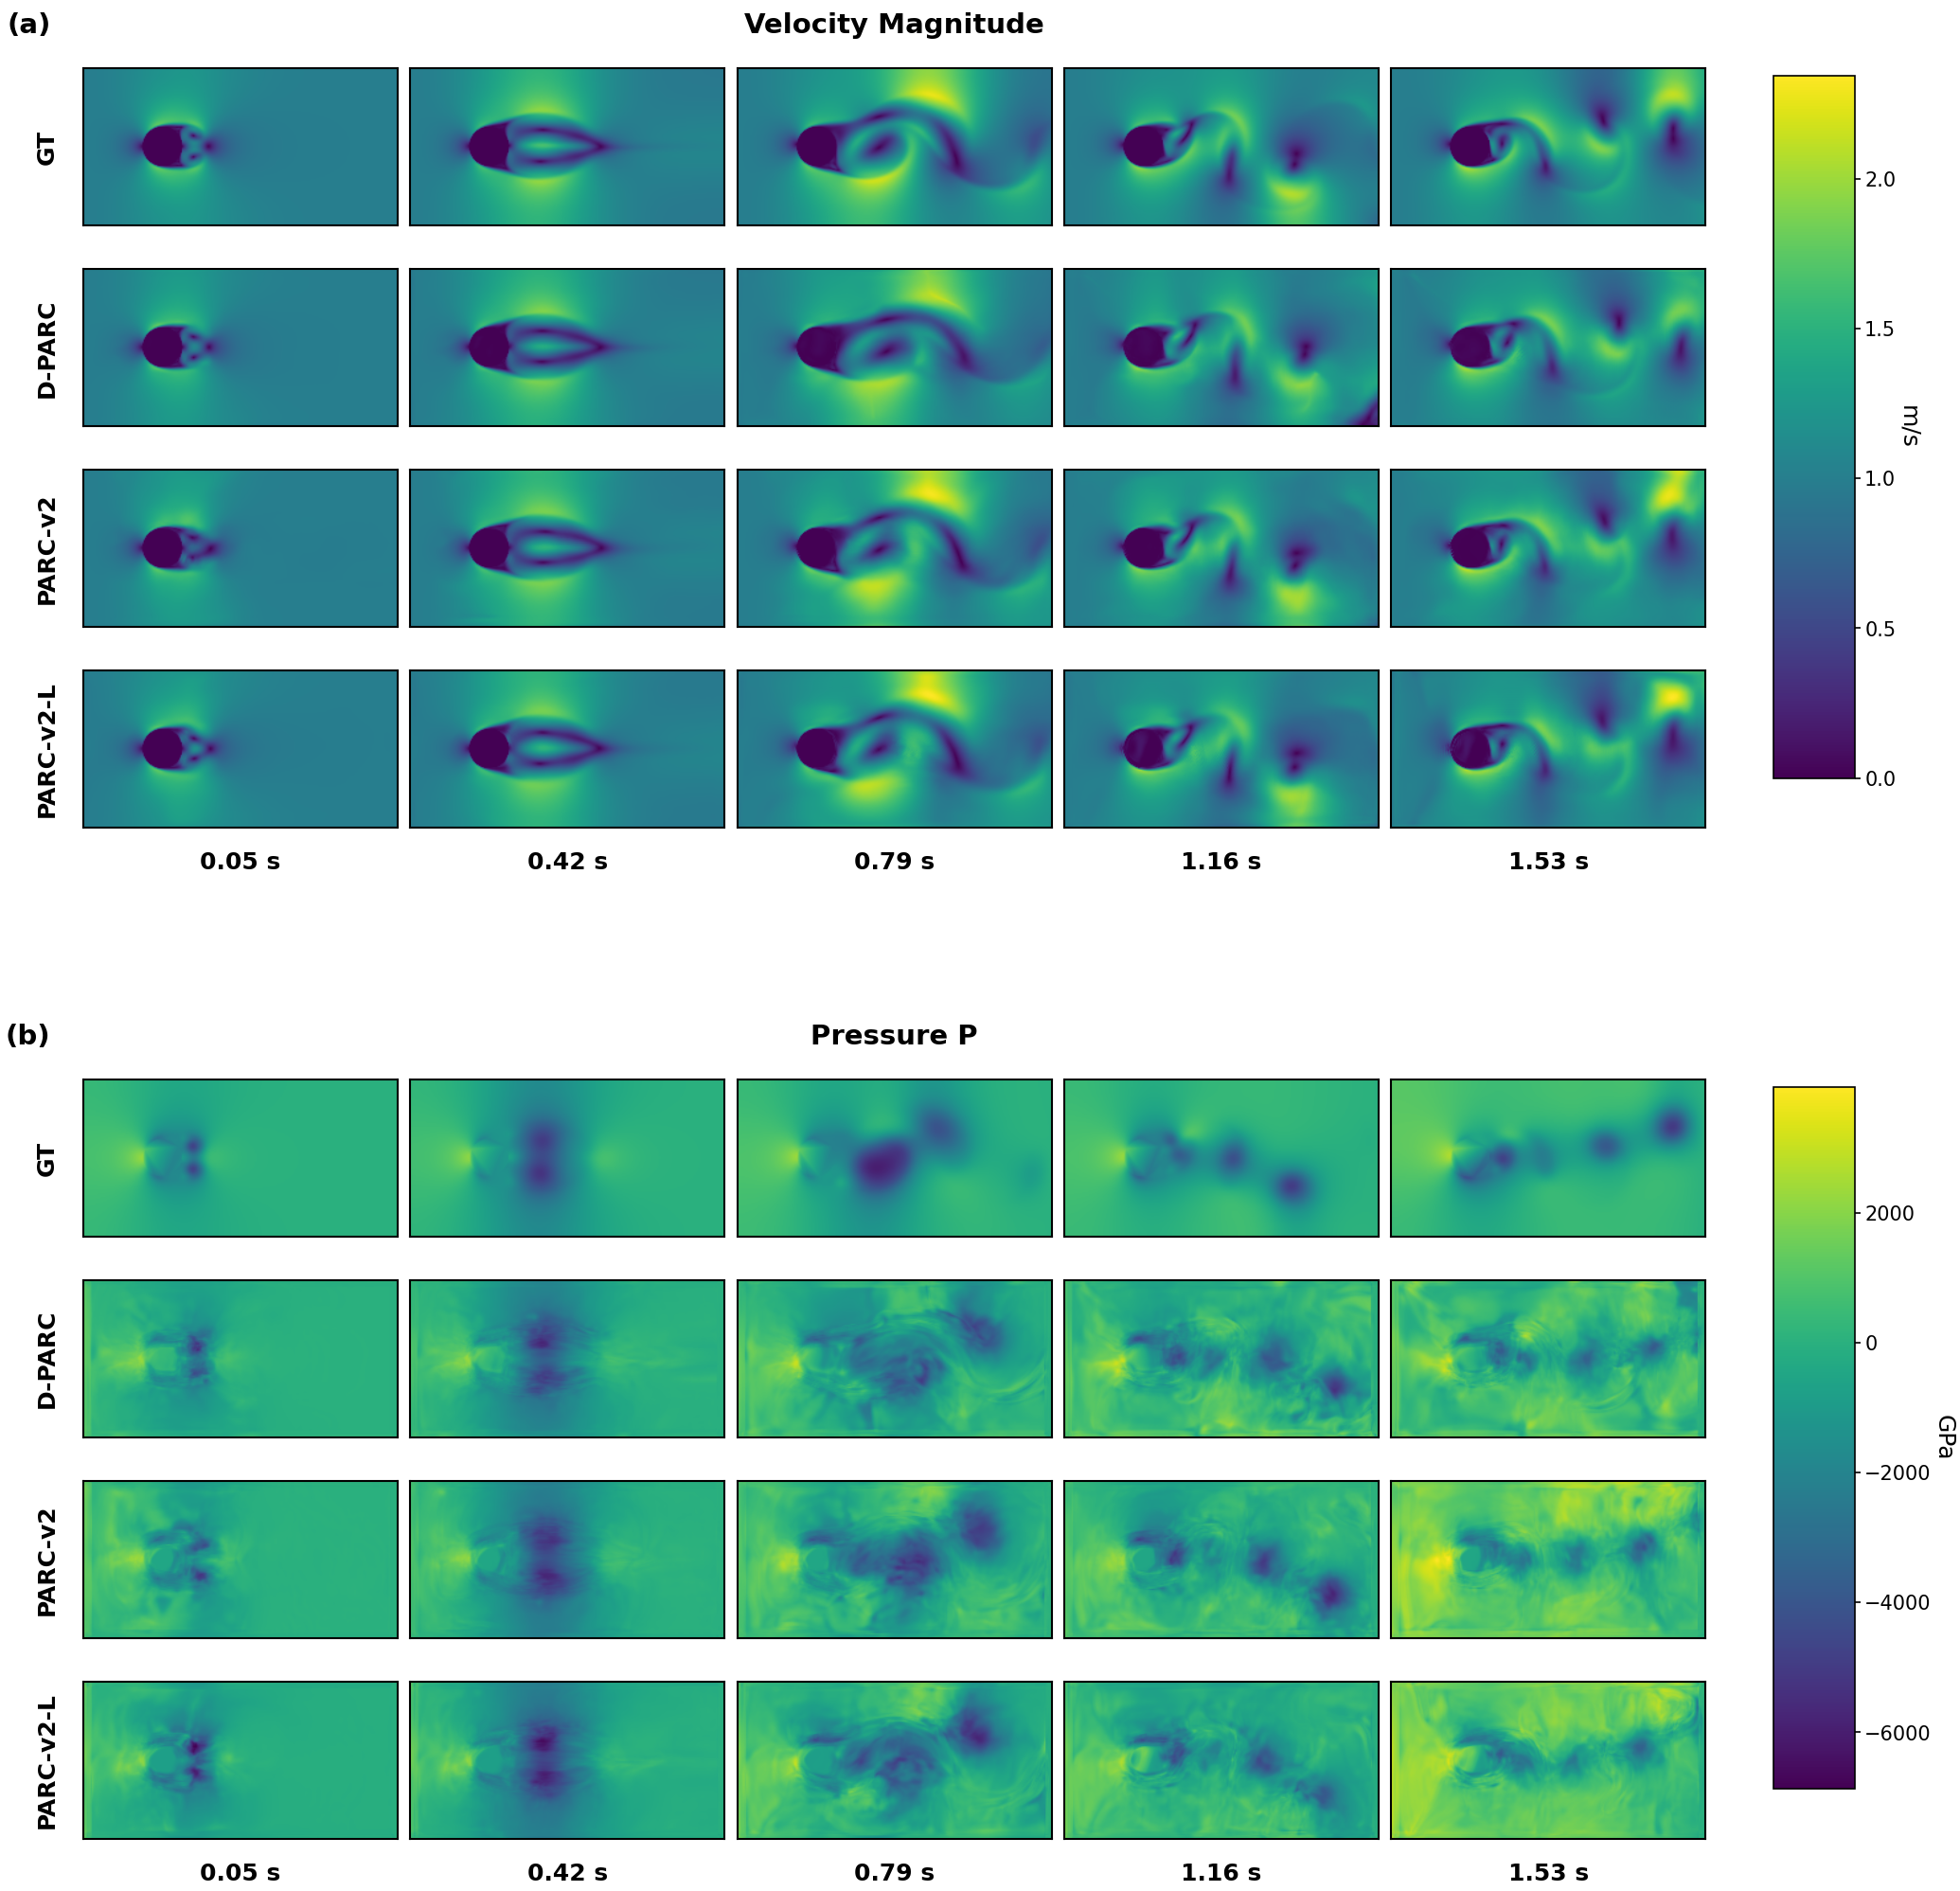

✓ Figure saved as PDF: ../results/comparison_ns/navierstokes_comparison_sample8.pdf
✓ Figure saved as PNG: ../results/comparison_ns/navierstokes_comparison_sample8.png

✓ Visualization complete!

Analysis Complete!

Dataset: Navier-Stokes
Sample visualized: 8


In [14]:
def set_publication_style():
    """Set publication-quality matplotlib style parameters."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 6,
        'axes.labelsize': 6,
        'axes.titlesize': 7,
        'xtick.labelsize': 5,
        'ytick.labelsize': 5,
        'legend.fontsize': 5,
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
        'axes.linewidth': 0.5,
        'xtick.major.width': 0.5,
        'ytick.major.width': 0.5,
    })


print("\nGenerating publication-quality visualization...")

if not data_to_plot or not features_to_plot:
    print("⚠️  No data available for plotting.")
else:
    set_publication_style()
    
    timesteps = config['viz_timesteps']
    num_features = len(features_to_plot)
    num_timesteps = len(timesteps)
    
    row_names = ['ground_truth', 'dparc', 'parc', 'large']
    row_labels = ['GT', 'D-PARC', 'PARC-v2', 'PARC-v2-L']
    num_models = len(row_names)
    
    # Determine figure sizing based on data aspect ratio
    first_grid = next(iter(next(iter(data_to_plot.values())).values()))['ground_truth']
    ny, nx = first_grid.shape
    data_aspect_ratio = ny / nx
    
    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    panel_height_in = (fig_width_in / num_timesteps) * data_aspect_ratio
    fig_height_in = panel_height_in * (num_models + 0.5) * num_features * 1.1
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    # Outer grid: features × (plots + colorbar)
    outer_gs = gridspec.GridSpec(
        num_features, 2, figure=fig,
        width_ratios=[1, 0.05],
        wspace=0.08, hspace=0.2,
        top=0.98, bottom=0.05, left=0.1, right=0.98
    )
    
    subfig_labels = ['a', 'b', 'c', 'd', 'e', 'f']
    
    # Determine origin based on dataset (solid mechanics uses 'lower', fluids use 'upper')
    origin = 'lower' if SELECTED_DATASET == 'energetic_materials' else 'upper'
    
    for i, feature in enumerate(features_to_plot):
        
        # Determine vmin/vmax for entire feature block
        all_grids = []
        for ts in timesteps:
            if ts not in data_to_plot[feature]:
                continue
            for model_name in row_names:
                if model_name in data_to_plot[feature][ts]:
                    all_grids.append(data_to_plot[feature][ts][model_name])
        
        if not all_grids:
            continue
        
        vmin = min(g.min() for g in all_grids)
        vmax = max(g.max() for g in all_grids)
        
        # Get colormap configuration
        # Check if we have a config for this feature
        if feature in viz_channels:
            cmap = viz_channels[feature]['cmap']
            cbar_label = viz_channels[feature]['label']
        elif feature == 'Velocity Magnitude':
            cmap = 'viridis'
            cbar_label = 'm/s'
        else:
            cmap = 'viridis'
            cbar_label = ''
        
        # Symmetrize for diverging colormaps
        if cmap in ['seismic', 'coolwarm', 'RdBu']:
            abs_max = max(abs(vmin), abs(vmax))
            vmin = -abs_max
            vmax = abs_max
        
        # Inner grid: title row + model rows × timesteps
        inner_gs_spec = outer_gs[i, 0]
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            num_models + 1, num_timesteps, subplot_spec=inner_gs_spec,
            height_ratios=[0.2] + [1] * num_models,
            hspace=0.02, wspace=0.04
        )
        
        # Feature title
        title_ax = fig.add_subplot(inner_gs[0, :])
        title_ax.text(-0.02, 0.5, f"({subfig_labels[i]})",
                     fontsize=7, weight='bold',
                     rotation=0, va='center', ha='right',
                     transform=title_ax.transAxes)
        
        feature_display = feature.replace('_', ' ').title()
        title_ax.text(0.5, 0.5, feature_display,
                     fontsize=7, weight='bold',
                     va='center', ha='center',
                     transform=title_ax.transAxes)
        title_ax.axis('off')
        
        # Plot grid
        im = None
        for row_idx, (row_name, row_label) in enumerate(zip(row_names, row_labels)):
            for j, ts in enumerate(timesteps):
                ax = fig.add_subplot(inner_gs[row_idx + 1, j])
                
                if ts in data_to_plot[feature] and row_name in data_to_plot[feature][ts]:
                    grid = data_to_plot[feature][ts][row_name]
                    im = ax.imshow(
                        grid, cmap=cmap, vmin=vmin, vmax=vmax,
                        interpolation='bilinear', aspect='equal',
                        origin=origin
                    )
                else:
                    ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                           transform=ax.transAxes, fontsize=5)
                
                # Time labels (bottom row)
                if row_idx == num_models - 1:
                    time_value = (ts + 1) * config['time_per_step']
                    # Format time label based on dataset
                    if SELECTED_DATASET == 'energetic_materials':
                        time_label = f"{time_value:.2f} ns"
                    else:
                        time_label = f"{time_value:.2f} s"
                    ax.text(0.5, -0.15, time_label, fontsize=6,
                           ha='center', va='top', transform=ax.transAxes,
                           weight='bold')
                
                # Model labels (first column)
                if j == 0:
                    ax.text(-0.08, 0.5, row_label, fontsize=6, weight='bold',
                           rotation=90, va='center', ha='right',
                           transform=ax.transAxes)
                
                ax.set_xticks([])
                ax.set_yticks([])
        
        # Colorbar
        if im:
            cbar_gs = gridspec.GridSpecFromSubplotSpec(
                3, 1, subplot_spec=outer_gs[i, 1],
                height_ratios=[0.1, 1, 0.1],
                hspace=0
            )
            cax = fig.add_subplot(cbar_gs[1, 0])
            
            cbar = plt.colorbar(im, cax=cax, aspect=15)
            cbar.ax.tick_params(labelsize=5, width=0.4, length=1.5, pad=1)
            cbar.outline.set_linewidth(0.4)
            if cbar_label:
                cbar.set_label(cbar_label, rotation=270, labelpad=6, fontsize=6)
    
    # Save figure
    dataset_name = SELECTED_DATASET.replace('_', '')
    output_filename_pdf = os.path.join(config['output_dir'], 
                                       f"{dataset_name}_comparison_sample{SAMPLE_ID_TO_COMPARE}.pdf")
    output_filename_png = os.path.join(config['output_dir'],
                                       f"{dataset_name}_comparison_sample{SAMPLE_ID_TO_COMPARE}.png")
    
    plt.savefig(output_filename_pdf)
    plt.savefig(output_filename_png)
    plt.show()
    plt.close(fig)
    
    print(f"✓ Figure saved as PDF: {output_filename_pdf}")
    print(f"✓ Figure saved as PNG: {output_filename_png}")

print("\n" + "="*80)
print("✓ Visualization complete!")
print("="*80)

# READY FOR ADDITIONAL ANALYSIS

print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)
print(f"\nDataset: {config['name']}")
print(f"Sample visualized: {SAMPLE_ID_TO_COMPARE}")


# ERF

In [15]:
################################################################################
# CELL 10: Multi-Point ERF Analysis - Setup
################################################################################



print("\n" + "="*80)
print(f"MULTI-POINT ERF ANALYSIS - {config['name']}")
print("="*80)

# Get ERF configuration
erf_cfg = config['erf_config']
SAMPLE_ID_TO_ANALYZE = erf_cfg['sample_id']
OUTPUT_POINT = erf_cfg['output_point']
ANALYZE_TIMESTEP = erf_cfg['analyze_timestep']
CHANNEL_TO_VISUALIZE = erf_cfg['channel_to_visualize']
CHANNEL_NAMES_VIZ = erf_cfg['channel_names']
CHANNEL_CMAPS = erf_cfg['channel_cmaps']
VMIN_VIZ = erf_cfg['vmin_viz']  # Can be None for auto-scale
VMAX_VIZ = erf_cfg['vmax_viz']  # Can be None for auto-scale
ERF_FORWARD_STEPS = ANALYZE_TIMESTEP + 2

# Multi-point configuration
REGION1_POINTS = erf_cfg['region1_points']
REGION2_POINTS = erf_cfg['region2_points']
REGION1_NAME = erf_cfg['region1_name']
REGION2_NAME = erf_cfg['region2_name']
TEST_THRESHOLDS = erf_cfg['test_thresholds']
PARCV2_TRF_AREA = erf_cfg['parcv2_trf_area']

# Output directory
OUTPUT_DIR = Path(config['output_dir']) / 'erf_multipoint_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ ERF Configuration:")
print(f"  Sample ID: {SAMPLE_ID_TO_ANALYZE}")
print(f"  Analysis timestep: T={ANALYZE_TIMESTEP}")
print(f"  Visualizing channel: {CHANNEL_NAMES_VIZ[CHANNEL_TO_VISUALIZE]}")
print(f"  Colormap range: {VMIN_VIZ if VMIN_VIZ is not None else 'Auto'} - {VMAX_VIZ if VMAX_VIZ is not None else 'Auto'}")
print(f"  {REGION1_NAME} points: {len(REGION1_POINTS)}")
print(f"  {REGION2_NAME} points: {len(REGION2_POINTS)}")
print(f"  PARCv2 Theoretical Receptive Field: {PARCV2_TRF_AREA} pixels")

# Load data
print("\nLoading data for ERF analysis...")
erf_dataset = GenericPhysicsDataset(
    data_dirs=[config['data_dir']],
    future_steps=ERF_FORWARD_STEPS,
    min_max_path=config['min_max_path']
)

# Check if sample ID is valid
if SAMPLE_ID_TO_ANALYZE >= len(erf_dataset):
    print(f"⚠️  SAMPLE_ID_TO_ANALYZE ({SAMPLE_ID_TO_ANALYZE}) is out of range! Using sample 0.")
    SAMPLE_ID_TO_ANALYZE = 0

# Get the specific sample
print(f"Loading sample {SAMPLE_ID_TO_ANALYZE}...")
sample_data = erf_dataset[SAMPLE_ID_TO_ANALYZE]
erf_batch = custom_collate_fn([sample_data])

erf_ic, erf_t0, erf_t1, _ = erf_batch
erf_ic = erf_ic.to(DEVICE)
erf_t0 = erf_t0.to(DEVICE)
erf_t1 = erf_t1.to(DEVICE)

print(f"✓ ERF data loaded for sample {SAMPLE_ID_TO_ANALYZE}. Initial condition shape: {erf_ic.shape}")


MULTI-POINT ERF ANALYSIS - Navier-Stokes

✓ ERF Configuration:
  Sample ID: 11
  Analysis timestep: T=24
  Visualizing channel: Velocity U
  Colormap range: Auto - Auto
  High Strain points: 3
  Low Strain points: 3
  PARCv2 Theoretical Receptive Field: 6084 pixels

Loading data for ERF analysis...


Listing samples: 100%|██████████| 13/13 [00:00<00:00, 868.32it/s]

Loading sample 11...
✓ ERF data loaded for sample 11. Initial condition shape: torch.Size([1, 4, 128, 256])


In [16]:
################################################################################
# CELL 11: ERF Helper Functions
################################################################################

def set_plot_style():
    """Publication-ready style."""
    plt.rcParams.update({
        'font.family': 'DejaVu Sans',
        'font.size': 8,
        'axes.labelsize': 8,
        'axes.titlesize': 9,
        'legend.fontsize': 7,
        'figure.dpi': 300,
        'axes.linewidth': 1.0,
    })


def denormalize_channel(normalized_data, channel_idx, norm_params):
    """Denormalize a single channel back to physical units."""
    channel_min = norm_params["channel_min"][channel_idx]
    channel_max = norm_params["channel_max"][channel_idx]
    return normalized_data * (channel_max - channel_min) + channel_min


def get_state_and_output(model, ic, t0, t1, target_timestep):
    """Run model forward to get state at timestep T and output at T+1."""
    model.eval()
    with torch.no_grad():
        if target_timestep == 0:
            state_at_t = ic.clone()
            t1_single = t1[:1]
            rollout = model(ic, t0, t1_single)
            output_at_t1 = rollout[0, :, :, :, :].clone()
        else:
            t1_partial = t1[:target_timestep+2]
            rollout = model(ic, t0, t1_partial)
            state_at_t = rollout[target_timestep, :, :, :, :].clone()
            output_at_t1 = rollout[target_timestep+1, :, :, :, :].clone()
    return state_at_t, output_at_t1


def compute_unet_erf_aggregate(model, input_state, output_point):
    """Compute UNet-only ERF aggregated across all output features."""
    unet = None
    possible_names = ['feature_extraction', 'feature_extractor', 'unet', 'network', 
                      'fe_network', 'encoder', 'feature_net']
    
    for attr_name in possible_names:
        if hasattr(model.differentiator, attr_name):
            unet = getattr(model.differentiator, attr_name)
            break
    
    if unet is None:
        raise AttributeError("Could not find UNet in model.differentiator")
    
    unet.eval()
    input_grad = input_state.detach().requires_grad_(True)
    
    with torch.set_grad_enabled(True):
        features = unet(input_grad)
        output_value = features[0, :, output_point[0], output_point[1]].sum()
    
    if input_grad.grad is not None:
        input_grad.grad.zero_()
    output_value.backward()
    
    if input_grad.grad is None:
        raise RuntimeError("Gradients are None!")
    
    gradients = input_grad.grad[0].detach().cpu().numpy()
    erf_map = np.abs(gradients)
    
    del input_grad, features, output_value
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    
    return erf_map


def compute_relative_sparsity_metrics(erf_map, thresholds, valid_domain_area):
    """Compute Relative Spatial Sparsity."""
    erf_agg = np.sum(erf_map, axis=0)
    erf_norm = erf_agg / (erf_agg.max() + 1e-10)
    
    results = {}
    for thresh in thresholds:
        erf_binary = (erf_norm > thresh).astype(float)
        activated = np.sum(erf_binary)
        sparsity = max(0, (1 - activated / valid_domain_area) * 100)
        
        results[thresh] = {
            'area': activated,
            'sparsity': sparsity
        }
    
    return results


def analyze_multiple_points(model, input_state, points, thresholds, point_type, valid_domain_area):
    """Analyze ERF at multiple points."""
    print(f"\n  Analyzing {len(points)} {point_type} points...")
    print(f"  -> Using Denominator: {valid_domain_area} pixels")
    
    results = {}
    
    for idx, point in enumerate(points):
        erf_map = compute_unet_erf_aggregate(model, input_state.clone(), point)
        metrics = compute_relative_sparsity_metrics(erf_map, thresholds, valid_domain_area)
        
        results[f'point_{idx+1}'] = {
            'coords': point,
            'erf_map': erf_map,
            'metrics': metrics
        }
    
    # Compute averages
    avg_metrics = {}
    for thresh in thresholds:
        areas = [results[f'point_{i+1}']['metrics'][thresh]['area'] 
                 for i in range(len(points))]
        sparsities = [results[f'point_{i+1}']['metrics'][thresh]['sparsity'] 
                      for i in range(len(points))]
        
        avg_metrics[thresh] = {
            'area_mean': np.mean(areas),
            'area_std': np.std(areas),
            'sparsity_mean': np.mean(sparsities),
            'sparsity_std': np.std(sparsities)
        }
    
    results['average'] = avg_metrics
    return results


print("✓ ERF helper functions defined")

✓ ERF helper functions defined


In [17]:
################################################################################
# CELL 12: Compute Multi-Point ERF
################################################################################

print(f"\nExtracting states at T={ANALYZE_TIMESTEP}...")
state_at_t_dparc, _ = get_state_and_output(model_dparc, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP)
state_at_t_parc, _ = get_state_and_output(model_parc, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP)
state_at_t_large, _ = get_state_and_output(model_large, erf_ic, erf_t0, erf_t1, ANALYZE_TIMESTEP)

print(f"✓ States extracted. Shape: {state_at_t_dparc.shape}")

# Get domain size
H, W = state_at_t_dparc.shape[-2], state_at_t_dparc.shape[-1]
GLOBAL_DOMAIN_AREA = H * W

print(f"\n{'='*80}")
print("COMPUTING ERF WITH MODEL-SPECIFIC DENOMINATORS")
print(f"{'='*80}")
print(f"Global Domain Size (HxW): {H}x{W} = {GLOBAL_DOMAIN_AREA} pixels")

# Calculate denominators
PARCV2_DENOMINATOR = min(PARCV2_TRF_AREA, GLOBAL_DOMAIN_AREA)
DPARC_DENOMINATOR = GLOBAL_DOMAIN_AREA

all_results = {
    'D-PARC': {'region1': None, 'region2': None},
    'PARC-v2': {'region1': None, 'region2': None},
    'Large': {'region1': None, 'region2': None}
}

# D-PARC
print(f"\n[1/3] D-PARC")
all_results['D-PARC']['region1'] = analyze_multiple_points(
    model_dparc, state_at_t_dparc, REGION1_POINTS, TEST_THRESHOLDS, REGION1_NAME,
    valid_domain_area=DPARC_DENOMINATOR
)
all_results['D-PARC']['region2'] = analyze_multiple_points(
    model_dparc, state_at_t_dparc, REGION2_POINTS, TEST_THRESHOLDS, REGION2_NAME,
    valid_domain_area=DPARC_DENOMINATOR
)

# PARC-v2
print(f"\n[2/3] PARC-v2")
print(f"-> Applying architectural constraint: {PARCV2_DENOMINATOR} pixels")
all_results['PARC-v2']['region1'] = analyze_multiple_points(
    model_parc, state_at_t_parc, REGION1_POINTS, TEST_THRESHOLDS, REGION1_NAME,
    valid_domain_area=PARCV2_DENOMINATOR
)
all_results['PARC-v2']['region2'] = analyze_multiple_points(
    model_parc, state_at_t_parc, REGION2_POINTS, TEST_THRESHOLDS, REGION2_NAME,
    valid_domain_area=PARCV2_DENOMINATOR
)

# Large
print(f"\n[3/3] Large")
all_results['Large']['region1'] = analyze_multiple_points(
    model_large, state_at_t_large, REGION1_POINTS, TEST_THRESHOLDS, REGION1_NAME,
    valid_domain_area=DPARC_DENOMINATOR
)
all_results['Large']['region2'] = analyze_multiple_points(
    model_large, state_at_t_large, REGION2_POINTS, TEST_THRESHOLDS, REGION2_NAME,
    valid_domain_area=DPARC_DENOMINATOR
)

print("\n✓ ERF computation complete!")


Extracting states at T=24...
✓ States extracted. Shape: torch.Size([1, 4, 128, 256])

COMPUTING ERF WITH MODEL-SPECIFIC DENOMINATORS
Global Domain Size (HxW): 128x256 = 32768 pixels

[1/3] D-PARC

  Analyzing 3 High Strain points...
  -> Using Denominator: 32768 pixels

  Analyzing 3 Low Strain points...
  -> Using Denominator: 32768 pixels

[2/3] PARC-v2
-> Applying architectural constraint: 6084 pixels

  Analyzing 3 High Strain points...
  -> Using Denominator: 6084 pixels

  Analyzing 3 Low Strain points...
  -> Using Denominator: 6084 pixels

[3/3] Large

  Analyzing 3 High Strain points...
  -> Using Denominator: 32768 pixels

  Analyzing 3 Low Strain points...
  -> Using Denominator: 32768 pixels

✓ ERF computation complete!


In [18]:
################################################################################
# CELL 13: Summary Tables
################################################################################

print("\n" + "="*80)
print("RELATIVE SPARSITY METRICS SUMMARY")
print("="*80)

def print_summary_table(point_type, title):
    print(f"\n📊 {title} (Relative Sparsity)")
    print(f"{'Threshold':<12} {'D-PARC':>30} {'PARC-v2':>30} {'Large':>30}")
    print(f"{'(% of max)':<12} {'Area':>15} {'Rel. Sparsity':>15} {'Area':>15} {'Rel. Sparsity':>15} {'Area':>15} {'Rel. Sparsity':>15}")
    print("-" * 115)
    
    for thresh in TEST_THRESHOLDS:
        print_data = [f"{thresh*100:>6.1f}%      "]
        
        for model in ['D-PARC', 'PARC-v2', 'Large']:
            avg = all_results[model][point_type]['average'][thresh]
            print_data.append(f"{avg['area_mean']:>7.0f}±{avg['area_std']:<6.0f}")
            print_data.append(f"{avg['sparsity_mean']:>6.2f}±{avg['sparsity_std']:<6.2f}")
        
        print(''.join(print_data))

print_summary_table('region1', f'{REGION1_NAME.upper()} REGION')
print_summary_table('region2', f'{REGION2_NAME.upper()} REGION')

print("\n" + "="*80)
print(f"SUMMARY AT 1% THRESHOLD - {config['name']}")
print("="*80)

t1 = 0.01
r1_d = all_results['D-PARC']['region1']['average'][t1]
r1_p = all_results['PARC-v2']['region1']['average'][t1]
r1_l = all_results['Large']['region1']['average'][t1]

r2_d = all_results['D-PARC']['region2']['average'][t1]
r2_p = all_results['PARC-v2']['region2']['average'][t1]
r2_l = all_results['Large']['region2']['average'][t1]

print(f"\n{REGION1_NAME} Regions (Relative Sparsity):")
print(f"  D-PARC:  {r1_d['sparsity_mean']:.2f}% ± {r1_d['sparsity_std']:.2f}% (Denominator: Global)")
print(f"  PARC-v2: {r1_p['sparsity_mean']:.2f}% ± {r1_p['sparsity_std']:.2f}% (Denominator: TRF={PARCV2_TRF_AREA})")
print(f"  Large:   {r1_l['sparsity_mean']:.2f}% ± {r1_l['sparsity_std']:.2f}% (Denominator: Global)")

print(f"\n{REGION2_NAME} Regions (Relative Sparsity):")
print(f"  D-PARC:  {r2_d['sparsity_mean']:.2f}% ± {r2_d['sparsity_std']:.2f}% (Denominator: Global)")
print(f"  PARC-v2: {r2_p['sparsity_mean']:.2f}% ± {r2_p['sparsity_std']:.2f}% (Denominator: TRF={PARCV2_TRF_AREA})")
print(f"  Large:   {r2_l['sparsity_mean']:.2f}% ± {r2_l['sparsity_std']:.2f}% (Denominator: Global)")


RELATIVE SPARSITY METRICS SUMMARY

📊 HIGH STRAIN REGION (Relative Sparsity)
Threshold                            D-PARC                        PARC-v2                          Large
(% of max)              Area   Rel. Sparsity            Area   Rel. Sparsity            Area   Rel. Sparsity
-------------------------------------------------------------------------------------------------------------------
   0.5%         7005±238    78.62±0.73     7455±1922    6.96±9.85    15666±1555   52.19±4.75  
   1.0%         3516±268    89.27±0.82     5545±2243   19.65±27.79    8181±1268   75.03±3.87  
   2.0%         1331±210    95.94±0.64     3457±1979   43.17±32.53    3263±563    90.04±1.72  
   3.0%          671±95     97.95±0.29     2293±1571   62.31±25.82    1713±231    94.77±0.70  
   5.0%          275±42     99.16±0.13     1158±941    80.97±15.47     744±51     97.73±0.16  
   7.5%          130±50     99.60±0.15      570±528    90.64±8.67      468±36     98.57±0.11  
  10.0%           72±3


GENERATING COMBINED PUBLICATION FIGURE

[Info] Building combined publication figure...

✓ Saved combined figure to: ../results/comparison_ns/erf_multipoint_analysis/COMBINED_high_strain_low_strain_T24.png
✓ Saved combined figure to: ../results/comparison_ns/erf_multipoint_analysis/COMBINED_high_strain_low_strain_T24.pdf


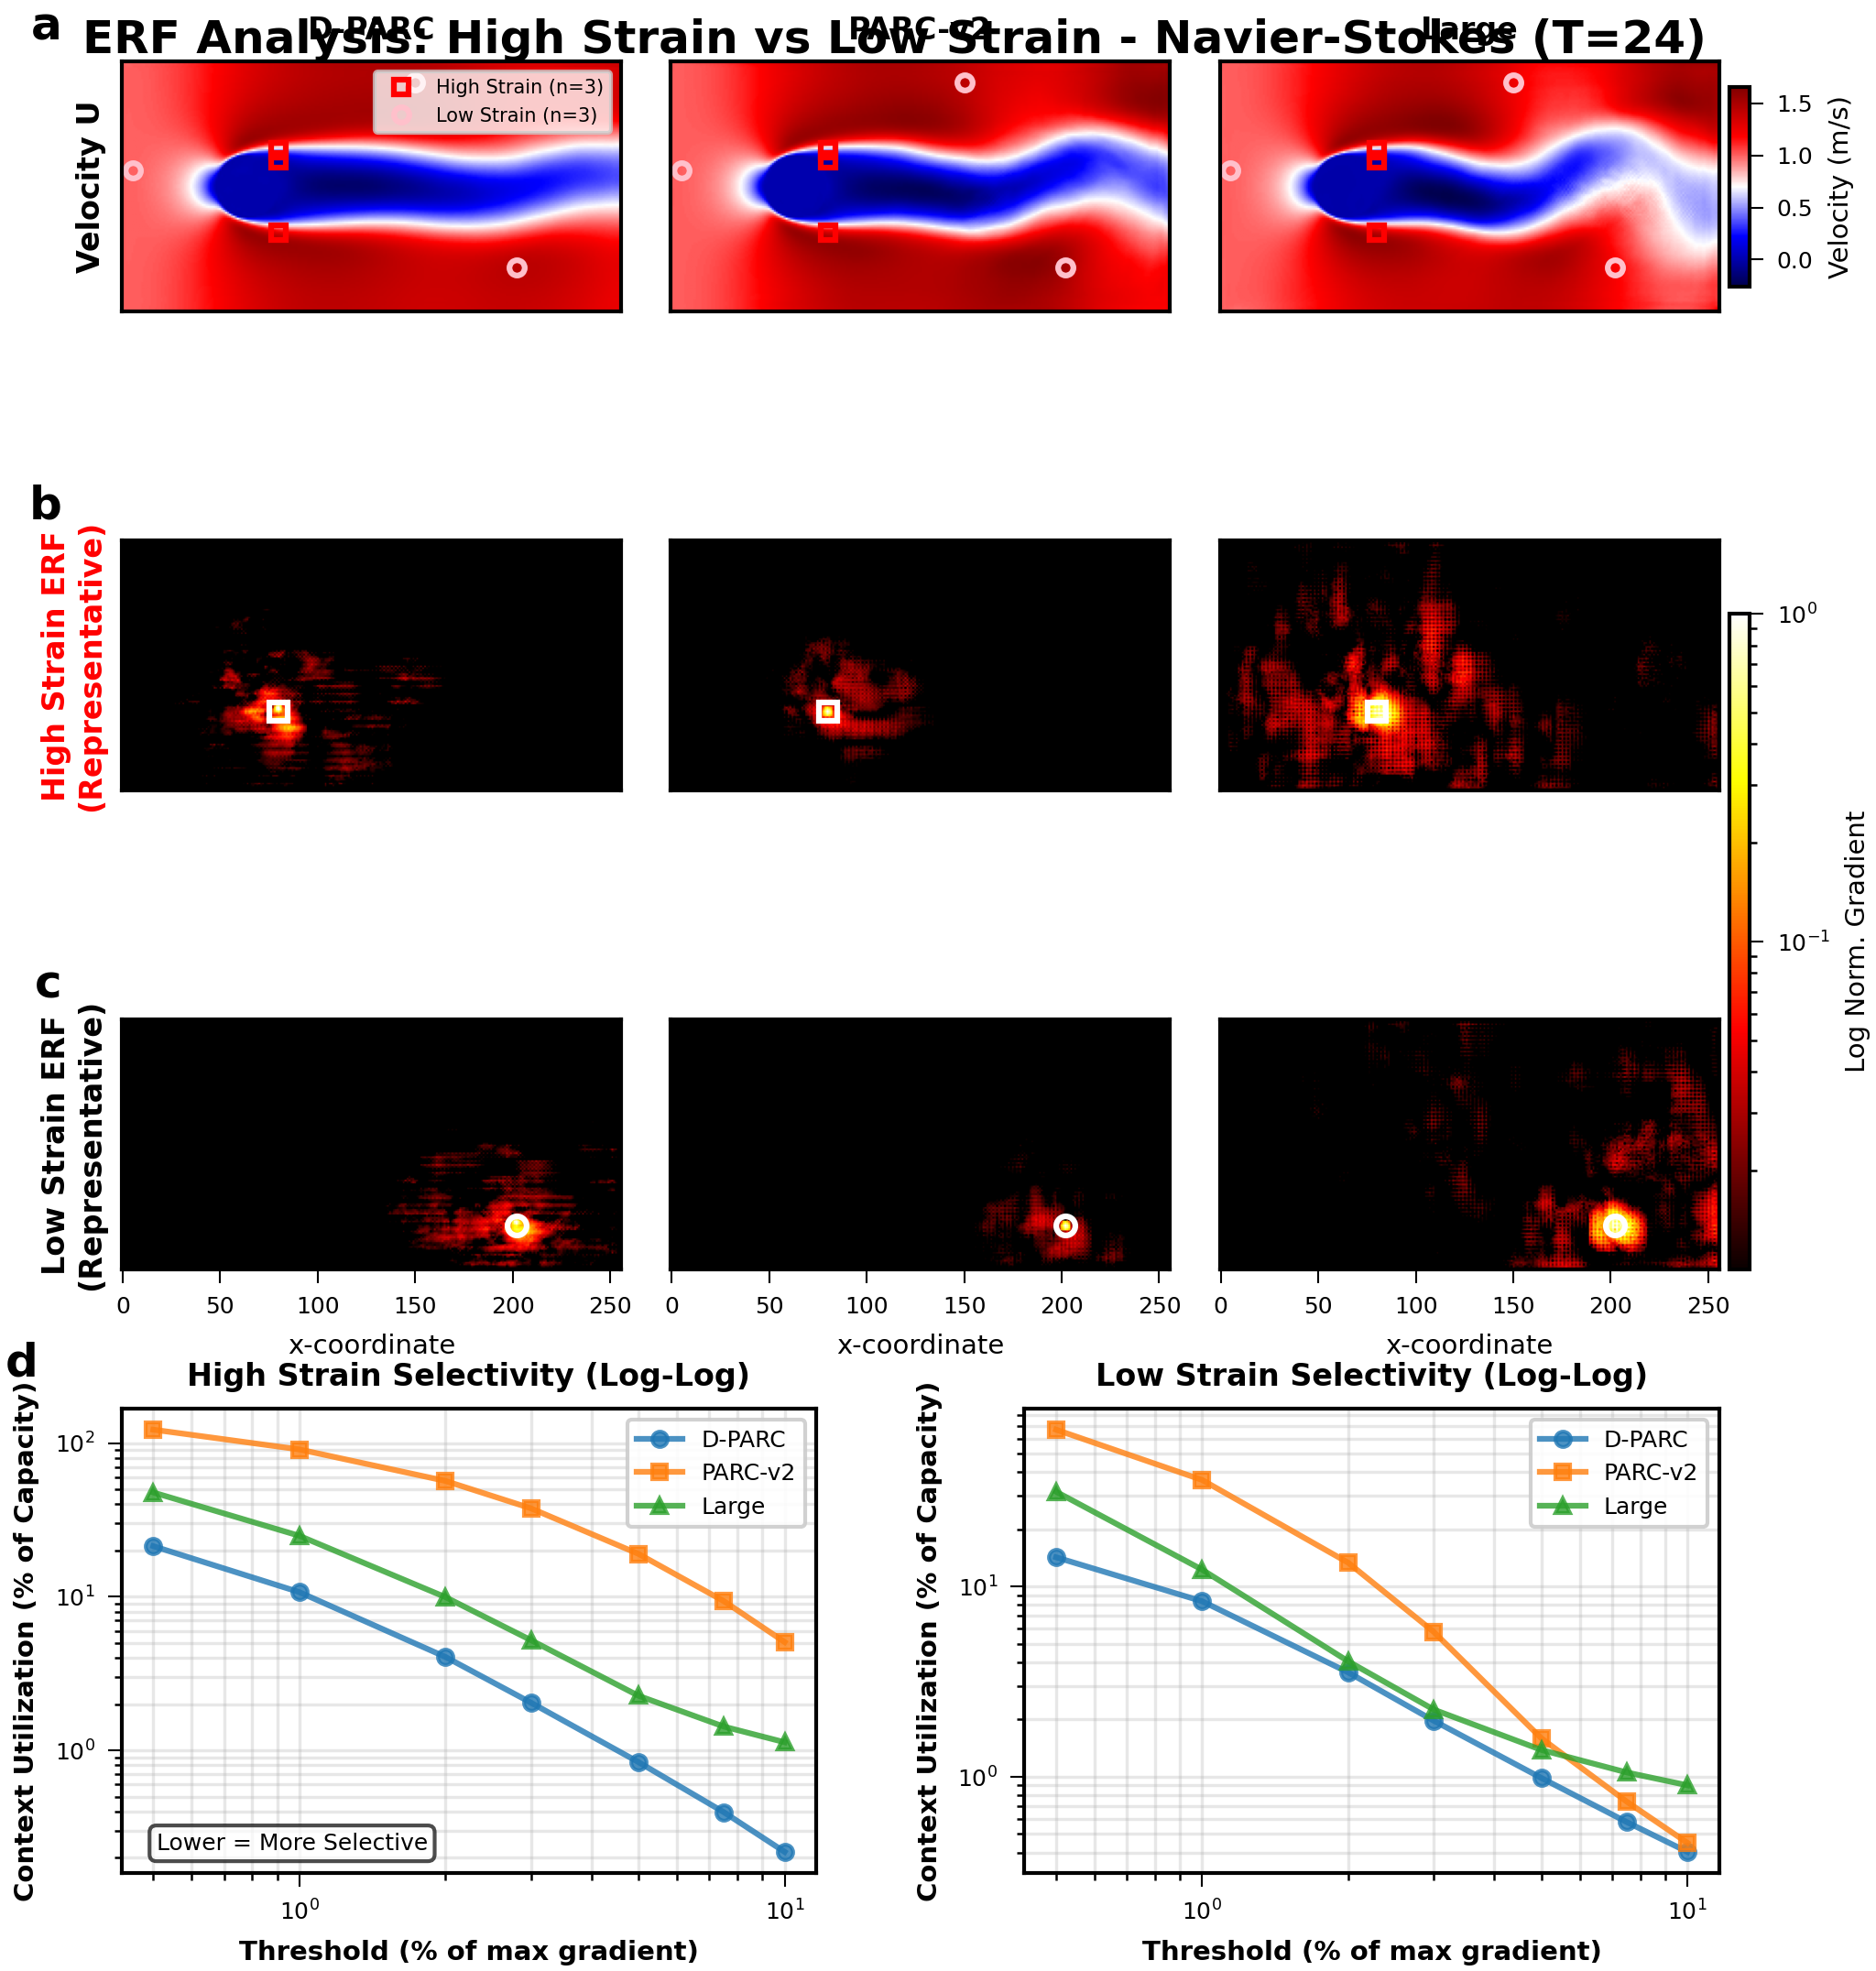


✓ Multi-point ERF analysis complete!


In [19]:
################################################################################
# CELL 14: Combined Publication Figure
################################################################################

print("\n" + "="*80)
print("GENERATING COMBINED PUBLICATION FIGURE")
print("="*80)

# Helper functions for plotting
def plot_panel_abc_temp_erf(
    fig, gs_panel,
    state_d_np, state_p_np, state_l_np,
    erf_r1_d_masked, erf_r1_p_masked, erf_r1_l_masked, point_r1,
    erf_r2_d_masked, erf_r2_p_masked, erf_r2_l_masked, point_r2,
    all_r1_points, all_r2_points,
    vmin, vmax, vmin_shared, origin, cmap_name, cbar_label
):
    """Draws the 3x3 grid (panels a, b, c)."""
    # Adjust hspace based on dataset
    if SELECTED_DATASET == 'energetic_materials':
        hspace = -0.52
    else:
        hspace = 0.1
    
    gs_sub = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=gs_panel,
                                                hspace=hspace, wspace=0.1)
    
    r1_marker_props = {'marker': 's', 'markersize': 4, 'markerfacecolor': 'none',
                       'markeredgecolor': 'red', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    r2_marker_props = {'marker': 'o', 'markersize': 4, 'markerfacecolor': 'none',
                       'markeredgecolor': 'pink', 'markeredgewidth': 1.5, 'linestyle': 'none'}
    
    temp_axes = []
    erf_axes = []
    ax_a_ref, ax_b_ref, ax_c_ref = None, None, None
    
    # Row 0: Panel (a) - Input field
    for col, (temp_data, title) in enumerate([
        (state_d_np, 'D-PARC'),
        (state_p_np, 'PARC-v2'),
        (state_l_np, 'Large')
    ]):
        ax = fig.add_subplot(gs_sub[0, col])
        if col == 0: ax_a_ref = ax
        im = ax.imshow(temp_data, cmap=cmap_name, origin=origin, vmin=vmin, vmax=vmax)
        temp_axes.append(ax)
        
        for pt in all_r1_points: ax.plot(pt[1], pt[0], **r1_marker_props)
        for pt in all_r2_points: ax.plot(pt[1], pt[0], **r2_marker_props)
        
        ax.set_title(title, fontweight='bold', fontsize=8)
        
        if col == 0:
            ax.set_ylabel(CHANNEL_NAMES_VIZ[CHANNEL_TO_VISUALIZE], fontweight='bold', fontsize=8)
            legend_elements = [
                Line2D([0], [0], **r1_marker_props, label=f'{REGION1_NAME} (n={len(all_r1_points)})'),
                Line2D([0], [0], **r2_marker_props, label=f'{REGION2_NAME} (n={len(all_r2_points)})')
            ]
            ax.legend(handles=legend_elements, fontsize=5, loc='upper right')
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Colorbar for input row
    pos_last_ax = temp_axes[-1].get_position()
    pos_first_ax = temp_axes[0].get_position()
    cbar_ax_temp = fig.add_axes([
        pos_last_ax.x1 + 0.005,
        pos_first_ax.y0 + pos_first_ax.height * 0.1,
        0.01,
        pos_first_ax.height * 0.8
    ])
    fig.colorbar(im, cax=cbar_ax_temp, label=cbar_label)
    cbar_ax_temp.yaxis.label.set_fontsize(7)
    cbar_ax_temp.tick_params(labelsize=6)
    
    # Row 1: Panel (b) - Region1 ERF
    for col, (erf_data, title) in enumerate([
        (erf_r1_d_masked, 'D-PARC'),
        (erf_r1_p_masked, 'PARC-v2'),
        (erf_r1_l_masked, 'Large')
    ]):
        ax = fig.add_subplot(gs_sub[1, col])
        if col == 0: ax_b_ref = ax
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot', origin=origin,
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_r1[1], point_r1[0], 's', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        if col == 0:
            ax.set_ylabel(f'{REGION1_NAME} ERF\n(Representative)', fontweight='bold', 
                         color='red', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Row 2: Panel (c) - Region2 ERF
    for col, (erf_data, title) in enumerate([
        (erf_r2_d_masked, 'D-PARC'),
        (erf_r2_p_masked, 'PARC-v2'),
        (erf_r2_l_masked, 'Large')
    ]):
        ax = fig.add_subplot(gs_sub[2, col])
        if col == 0: ax_c_ref = ax
        ax.set_facecolor('black')
        im_erf = ax.imshow(erf_data, cmap='hot', origin=origin,
                           norm=LogNorm(vmin=vmin_shared, vmax=1.0))
        erf_axes.append(ax)
        ax.plot(point_r2[1], point_r2[0], 'o', markersize=5,
                markerfacecolor='none', markeredgecolor='white', markeredgewidth=1.5)
        ax.set_xlabel('x-coordinate', fontsize=7)
        if col == 0:
            ax.set_ylabel(f'{REGION2_NAME} ERF\n(Representative)', fontweight='bold', 
                         color='black', fontsize=8)
        
        ax.tick_params(axis='x', labelsize=6)
        ax.set_yticks([])
    
    # Colorbar for ERF rows
    pos_last_ax_low = erf_axes[-1].get_position()
    pos_first_ax_high = erf_axes[0].get_position()
    cbar_ax_erf = fig.add_axes([
        pos_last_ax_low.x1 + 0.005,
        pos_last_ax_low.y0,
        0.01,
        (pos_first_ax_high.y1 - pos_last_ax_low.y0) * 0.9
    ])
    fig.colorbar(im_erf, cax=cbar_ax_erf, label='Log Norm. Gradient')
    cbar_ax_erf.yaxis.label.set_fontsize(7)
    cbar_ax_erf.tick_params(labelsize=6)
    
    # Panel labels
    label_props = {'fontsize': 12, 'fontweight': 'bold', 'va': 'bottom', 'ha': 'right'}
    ax_a_ref.text(-0.12, 1.05, 'a', transform=ax_a_ref.transAxes, **label_props)
    ax_b_ref.text(-0.12, 1.05, 'b', transform=ax_b_ref.transAxes, **label_props)
    ax_c_ref.text(-0.12, 1.05, 'c', transform=ax_c_ref.transAxes, **label_props)


def plot_panel_d_utilization(fig, gs_panel, r1_areas, r2_areas, thresholds, 
                             parcv2_denom, dparc_denom, r1_name, r2_name):
    """Draws the 1x2 grid for Context Utilization as Panel (d)."""
    gs_sub = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_panel, wspace=0.3)
    
    thresh_percent = np.array(thresholds) * 100
    line_props = {'linewidth': 1.5, 'markersize': 4, 'alpha': 0.8}
    
    denoms = {'D-PARC': dparc_denom, 'PARC-v2': parcv2_denom, 'Large': dparc_denom}
    
    def get_util(model_name, area_list):
        return [(a / denoms[model_name]) * 100 for a in area_list]
    
    # Region1 (left plot)
    ax = fig.add_subplot(gs_sub[0, 0])
    ax.text(-0.12, 1.05, 'd', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='bottom', ha='right')
    
    for model, marker in [('D-PARC', 'o-'), ('PARC-v2', 's-'), ('Large', '^-')]:
        y_vals = get_util(model, r1_areas[model])
        ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)
    
    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
    ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold', fontsize=7)
    ax.set_title(f'{r1_name} Selectivity (Log-Log)', fontweight='bold', fontsize=8)
    ax.legend(framealpha=0.9, fontsize=6)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=6)
    ax.text(0.05, 0.05, 'Lower = More Selective', transform=ax.transAxes, 
            fontsize=6, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    
    # Region2 (right plot)
    ax = fig.add_subplot(gs_sub[0, 1])
    
    for model, marker in [('D-PARC', 'o-'), ('PARC-v2', 's-'), ('Large', '^-')]:
        y_vals = get_util(model, r2_areas[model])
        ax.loglog(thresh_percent, y_vals, marker, label=model, **line_props)
    
    ax.set_xlabel('Threshold (% of max gradient)', fontweight='bold', fontsize=7)
    ax.set_ylabel('Context Utilization (% of Capacity)', fontweight='bold', fontsize=7)
    ax.set_title(f'{r2_name} Selectivity (Log-Log)', fontweight='bold', fontsize=8)
    ax.legend(framealpha=0.9, fontsize=6)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=6)


# Prepare data
set_plot_style()

# Denormalize states
state_d_np = denormalize_channel(state_at_t_dparc[0, CHANNEL_TO_VISUALIZE].cpu().numpy(), 
                                  CHANNEL_TO_VISUALIZE, norm_params)
state_p_np = denormalize_channel(state_at_t_parc[0, CHANNEL_TO_VISUALIZE].cpu().numpy(), 
                                  CHANNEL_TO_VISUALIZE, norm_params)
state_l_np = denormalize_channel(state_at_t_large[0, CHANNEL_TO_VISUALIZE].cpu().numpy(), 
                                  CHANNEL_TO_VISUALIZE, norm_params)

# Auto-scale if needed
if VMIN_VIZ is None:
    vmin = min(state_d_np.min(), state_p_np.min(), state_l_np.min())
else:
    vmin = VMIN_VIZ

if VMAX_VIZ is None:
    vmax = max(state_d_np.max(), state_p_np.max(), state_l_np.max())
else:
    vmax = VMAX_VIZ

# Process ERF maps
def process_erf(erf_map):
    erf_agg = np.sum(erf_map, axis=0)
    erf_norm = erf_agg / (erf_agg.max() + 1e-10)
    threshold = 0.01
    return np.where(erf_norm > threshold, erf_norm, np.nan)

erf_r1_d = process_erf(all_results['D-PARC']['region1']['point_1']['erf_map'])
erf_r1_p = process_erf(all_results['PARC-v2']['region1']['point_1']['erf_map'])
erf_r1_l = process_erf(all_results['Large']['region1']['point_1']['erf_map'])
point_r1 = REGION1_POINTS[0]

erf_r2_d = process_erf(all_results['D-PARC']['region2']['point_1']['erf_map'])
erf_r2_p = process_erf(all_results['PARC-v2']['region2']['point_1']['erf_map'])
erf_r2_l = process_erf(all_results['Large']['region2']['point_1']['erf_map'])
point_r2 = REGION2_POINTS[0]

def safe_nanmin(arr, default=1e-3):
    valid = arr[~np.isnan(arr)]
    return valid.min() if len(valid) > 0 else default

vmin_shared = min([
    safe_nanmin(erf_r1_d), safe_nanmin(erf_r1_p), safe_nanmin(erf_r1_l),
    safe_nanmin(erf_r2_d), safe_nanmin(erf_r2_p), safe_nanmin(erf_r2_l)
])

# Prepare area data for panel d
r1_areas = {
    'D-PARC': [all_results['D-PARC']['region1']['average'][t]['area_mean'] for t in TEST_THRESHOLDS],
    'PARC-v2': [all_results['PARC-v2']['region1']['average'][t]['area_mean'] for t in TEST_THRESHOLDS],
    'Large': [all_results['Large']['region1']['average'][t]['area_mean'] for t in TEST_THRESHOLDS]
}
r2_areas = {
    'D-PARC': [all_results['D-PARC']['region2']['average'][t]['area_mean'] for t in TEST_THRESHOLDS],
    'PARC-v2': [all_results['PARC-v2']['region2']['average'][t]['area_mean'] for t in TEST_THRESHOLDS],
    'Large': [all_results['Large']['region2']['average'][t]['area_mean'] for t in TEST_THRESHOLDS]
}

# Determine origin and colorbar label
origin = 'lower' if SELECTED_DATASET == 'energetic_materials' else 'upper'
cmap_name = CHANNEL_CMAPS[CHANNEL_TO_VISUALIZE]

# Get appropriate colorbar label
if SELECTED_DATASET == 'energetic_materials':
    if CHANNEL_TO_VISUALIZE == 0:
        cbar_label = 'Temperature (K)'
    elif CHANNEL_TO_VISUALIZE == 1:
        cbar_label = 'Pressure (Pa)'
    else:
        cbar_label = CHANNEL_NAMES_VIZ[CHANNEL_TO_VISUALIZE]
elif SELECTED_DATASET == 'navier_stokes':
    if CHANNEL_TO_VISUALIZE == 1:
        cbar_label = 'Pressure (Pa)'
    else:
        cbar_label = 'Velocity (m/s)'
else:  # burgers
    cbar_label = 'Velocity (m/s)'

# Create figure
print("\n[Info] Building combined publication figure...")
fig = plt.figure(figsize=(7.5, 9))

main_gs = gridspec.GridSpec(2, 1, figure=fig,
                            height_ratios=[3, 1], hspace=0.05)

gs_abc = main_gs[0]
gs_d = main_gs[1]

# Plot panels
plot_panel_abc_temp_erf(
    fig, gs_abc,
    state_d_np, state_p_np, state_l_np,
    erf_r1_d, erf_r1_p, erf_r1_l, point_r1,
    erf_r2_d, erf_r2_p, erf_r2_l, point_r2,
    REGION1_POINTS, REGION2_POINTS,
    vmin, vmax, vmin_shared, origin, cmap_name, cbar_label
)

plot_panel_d_utilization(
    fig, gs_d,
    r1_areas, r2_areas, TEST_THRESHOLDS,
    parcv2_denom=PARCV2_DENOMINATOR,
    dparc_denom=DPARC_DENOMINATOR,
    r1_name=REGION1_NAME,
    r2_name=REGION2_NAME
)

# Finalize
fig.suptitle(f'ERF Analysis: {REGION1_NAME} vs {REGION2_NAME} - {config["name"]} (T={ANALYZE_TIMESTEP})',
             fontsize=12, fontweight='bold', y=0.86)

output_path = OUTPUT_DIR / f'COMBINED_{REGION1_NAME.lower().replace(" ", "_")}_{REGION2_NAME.lower().replace(" ", "_")}_T{ANALYZE_TIMESTEP}.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"\n✓ Saved combined figure to: {output_path}")

output_path_pdf = output_path.with_suffix('.pdf')
plt.savefig(output_path_pdf, bbox_inches='tight')
print(f"✓ Saved combined figure to: {output_path_pdf}")

plt.show()
plt.close(fig)
gc.collect()

print("\n" + "="*80)
print("✓ Multi-point ERF analysis complete!")
print("="*80)

# Individual

# HMX

In [20]:
################################################################################
# CELL 1: Load Data and Perform Global Clustering (Run this cell only once)
################################################################################

#!/usr/bin/env python3
"""
CELL 1: Data Loading and Global Processing

This cell loads the unified CSV data file into a pandas DataFrame and performs
global K-Means clustering on the entire dataset. It should be run once to make
the processed data available for the visualization cell that follows.
"""

import pandas as pd
from pathlib import Path
import logging
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
import numpy as np

# ------------------------------------------------------------------- #
# Configuration - EDIT THIS VALUE
# ------------------------------------------------------------------- #
# Path to the unified data CSV file.
CSV_PATH = '/home/jtb3sud/PARCtorch/PARCtorch/scripts/eval_results/hmx/per_pixel_analysis_job_2637997/ALL_SAMPLES_upBlock_3_unified_data.csv'

# --- Setup ---
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# --- Load and Process Data from CSV ---
display(Markdown(f"### Loading data from `{CSV_PATH}`..."))
try:
    df = pd.read_csv(CSV_PATH)
    display(Markdown(f"**Successfully loaded data with {len(df)} rows.**"))
    
    # --- Perform global K-Means clustering on the ENTIRE dataframe ---
    if 'strain_rate_magnitude' in df.columns:
        logging.info("Performing global K-Means clustering on the entire CSV's strain data...")
        strain_values = df[['strain_rate_magnitude']].values
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(strain_values)
        centers = kmeans.cluster_centers_.flatten()
        label_map = {np.argmin(centers): "low", np.argmax(centers): "high"}
        df['strain_category'] = kmeans.predict(strain_values)
        df['strain_category'] = df['strain_category'].map(label_map)
        logging.info("Global clustering complete. 'strain_category' column added.")
    
    display(df.head())
    
    available_samples = sorted(df['sample_id'].unique())
    display(Markdown(f"**Available `sample_id` values:** `{available_samples}`"))
    
except FileNotFoundError:
    logging.error(f"Error: CSV file not found at {CSV_PATH}")
    df = None

### Loading data from `/home/jtb3sud/PARCtorch/PARCtorch/scripts/eval_results/hmx/per_pixel_analysis_job_2637997/ALL_SAMPLES_upBlock_3_unified_data.csv`...

**Successfully loaded data with 15138816 rows.**

,anisotropy,orientation,ellipse_area,shear_magnitude,deformation_magnitude,centroid_skew_magnitude,sample_id,timestep,pixel_y,pixel_x,...,offset_k4_dx,offset_k5_dy,offset_k5_dx,offset_k6_dy,offset_k6_dx,offset_k7_dy,offset_k7_dx,offset_k8_dy,offset_k8_dx,strain_category
0,1.72837,99.8258,0.544126,0.044890,0.897663,0.657450,0,0,0,0,...,-0.192011,0.214912,-0.116833,-0.054899,1.166870,-0.394373,0.264102,-0.082831,-0.127238,low
1,11.15100,99.3157,0.409407,0.133446,1.168640,0.522894,0,0,0,1,...,-1.044490,0.454250,-0.737772,-0.174426,0.739307,-0.376365,0.289990,-0.234415,-0.870750,low
2,14.27360,98.0131,0.498646,0.119964,1.256860,0.415934,0,0,0,2,...,-1.491630,0.348096,-0.949297,-0.208395,0.692051,-0.404975,0.334967,-0.336500,-1.137830,low
3,14.61610,98.8145,0.505113,0.132033,1.264040,0.404223,0,0,0,3,...,-1.518630,0.347181,-0.984191,-0.224456,0.700159,-0.427169,0.329689,-0.309857,-1.165180,low
4,16.40910,99.1750,0.482734,0.139326,1.275230,0.426769,0,0,0,4,...,-1.490070,0.381424,-0.977012,-0.226798,0.714672,-0.442819,0.330513,-0.288868,-1.149740,low


**Available `sample_id` values:** `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]`

/tmp/ipykernel_557175/3689073276.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_557175/3689073276.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure 1 (A-D) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/em_combined_vis_from_notebook/fig1_abcd_3_sample12_strain_rate_magnitude.pdf`

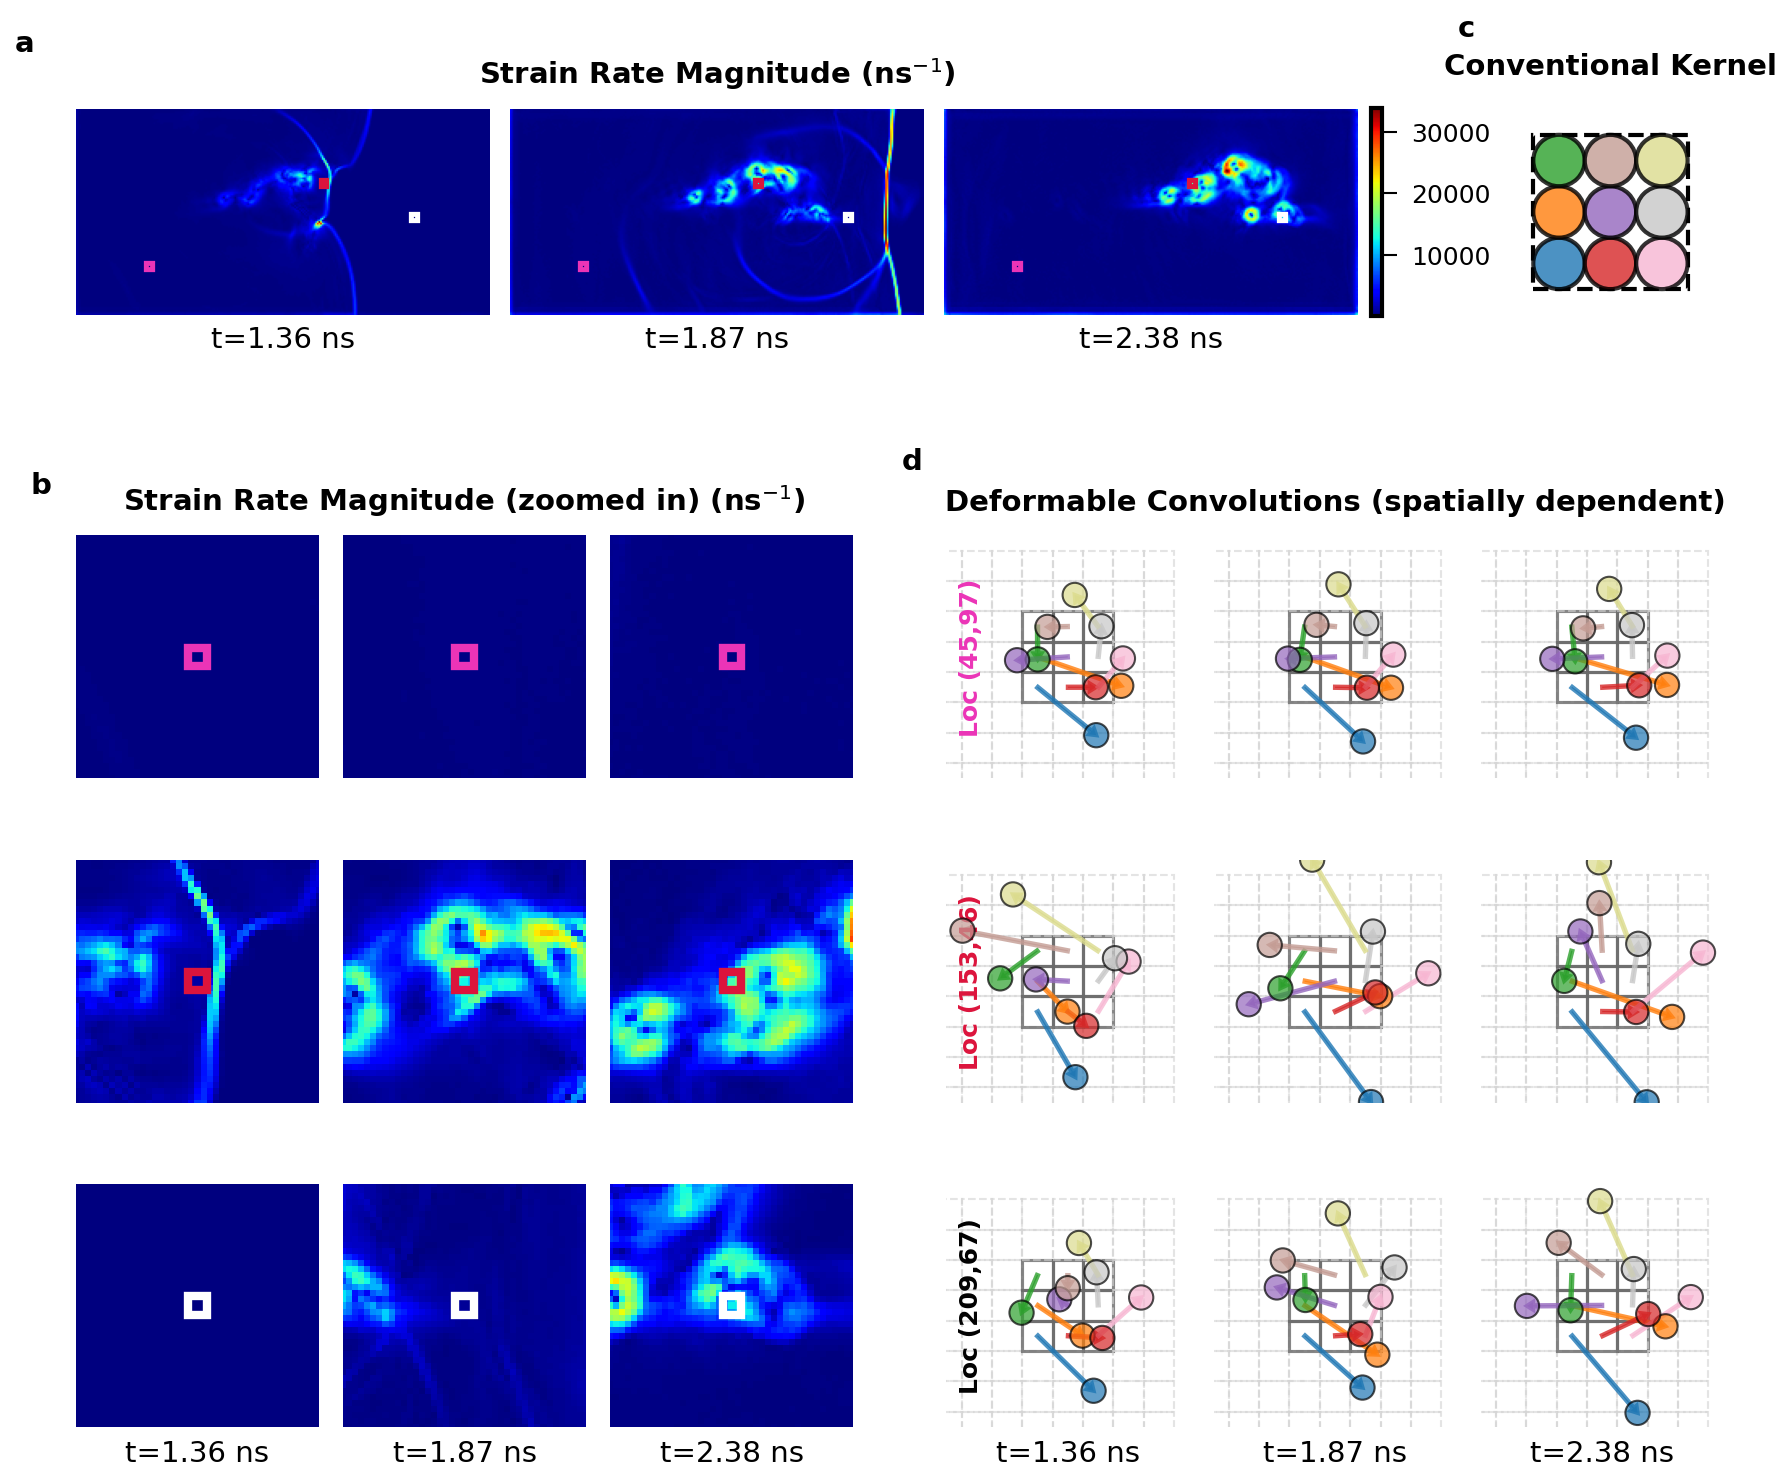

In [21]:
#!/usr/bin/env python3
"""
Figure 1: Panels A, B, C, D - Spatial Visualization
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Circle
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "em_combined_vis_from_notebook"
VISUALIZATION_METRIC = 'strain_rate_magnitude'
SPATIAL_LOCATIONS = [45, 97, 153, 46, 209, 67]
TIMESTEPS = [7, 10, 13]  # keep actual timesteps for data extraction
SAMPLE_ID = 12

# Mapping for display labels only
TIMESTEP_LABELS = {
    7: "1.36 ns",
    10: "1.87 ns",
    13: "2.38 ns"
}

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found. Please define it with the path to your data file.")

# Static variables
color_map = plt.get_cmap("tab20")
kernel_colors = [color_map(i) for i in np.linspace(0, 1, 9, endpoint=False)]
grid_coords = np.array([[-1,-1],[-1,0],[-1,1],[0,-1],[0,0],[0,1],[1,-1],[1,0],[1,1]], dtype=np.float32)
zoom_limits = {"initial_doubleConv": 3, "upBlock_3": 3}

def set_publication_style():
    plt.rcParams.update({
        #'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_abcd_figure(spatial_locations, display_channels_by_ts, offset_fields_by_ts,
                         layer_key, output_path, title_prefix):
    set_publication_style()
    num_locations = len(spatial_locations)
    timesteps_to_plot = sorted(display_channels_by_ts.keys())
    num_ts = len(timesteps_to_plot)

    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * (0.28 * num_locations + 0.5)
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    
    gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, num_locations * 0.35], hspace=-0.46)
    a_c_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0],
                                              width_ratios=[num_ts, 0.5], wspace=0.08)
    a_gs = gridspec.GridSpecFromSubplotSpec(1, num_ts, subplot_spec=a_c_gs[0, 0], wspace=0.05)
    b_d_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                              width_ratios=[1, 1], wspace=0.12)
    
    b_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 0],
                                            wspace=0.1, hspace=-0.6)
    d_gs = gridspec.GridSpecFromSubplotSpec(num_locations, num_ts, subplot_spec=b_d_gs[0, 1],
                                            wspace=0.1, hspace=-0.6)

    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    cmap = "jet"

    # Changed: white square instead of black
    rec_colors = ['#eb34b7', 'crimson', '#FFFFFF', '#34eb3d']

    H_offset, W_offset = next(iter(display_channels_by_ts.values())).shape

    # Panel A - Single title above all three timesteps
    panel_a_ims = []  # Store image objects
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        ax_full_view = fig.add_subplot(a_gs[0, i])
        im = ax_full_view.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
        panel_a_ims.append(im)
        
        # Display label from TIMESTEP_LABELS mapping
        ts_label = TIMESTEP_LABELS.get(ts, str(ts))
        
        # Only show title on the middle subplot (i == 1)
        if i == 1:
            ax_full_view.set_title(f"{title_prefix} (ns$^{{-1}}$)", fontsize=7, weight='bold')
        
        # Add time label at bottom
        ax_full_view.text(0.5, -0.05, f"t={ts_label}", transform=ax_full_view.transAxes,
                         ha='center', va='top', fontsize=7)
    
        ax_full_view.axis('off')
        if i == 0:
            ax_full_view.text(-0.1, 1.25, 'a', transform=ax_full_view.transAxes, **label_props)
        
        for loc_idx, (cur_x, cur_y) in enumerate(spatial_locations):
            ax_full_view.add_patch(Rectangle((cur_x - 1.5, cur_y - 1.5), 3, 3, lw=1.5,
                                             ec=rec_colors[loc_idx % len(rec_colors)], fc='none'))
    
    # Add colorbar without label
    cbar = fig.colorbar(panel_a_ims[-1], ax=fig.axes[:num_ts], fraction=0.046, pad=0.01, shrink=0.15)
    cbar.ax.tick_params(labelsize=6)
    
    # Panel B - Single title with "zoomed in"
    for i, ts in enumerate(timesteps_to_plot):
        pred_channel = display_channels_by_ts[ts]
        ts_label = TIMESTEP_LABELS.get(ts, str(ts))
        for zoom_idx, (zoom_loc_x, zoom_loc_y) in enumerate(spatial_locations):
            ax_zoom = fig.add_subplot(b_gs[zoom_idx, i])
            if zoom_idx == 0 and i == 1:
                # Show title with "zoomed in" only on middle subplot of top row
                ax_zoom.set_title(f"{title_prefix} (zoomed in) (ns$^{{-1}}$)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if zoom_idx == num_locations - 1:
                ax_zoom.text(0.5, -0.05, f"t={ts_label}", transform=ax_zoom.transAxes,
                           ha='center', va='top', fontsize=7)
            
            ax_zoom.imshow(pred_channel, cmap=cmap, extent=[-0.5, W_offset - 0.5, H_offset - 0.5, -0.5])
            ax_zoom.set_xlim(zoom_loc_x - 20, zoom_loc_x + 20)
            ax_zoom.set_ylim(zoom_loc_y + 20, zoom_loc_y - 20)
            ax_zoom.set_aspect('equal', adjustable='box')
            ax_zoom.add_patch(Rectangle((zoom_loc_x - 1.5, zoom_loc_y - 1.5), 3, 3, lw=2,
                                        ec=rec_colors[zoom_idx % len(rec_colors)], fc='none'))
            ax_zoom.axis('off')
            if i == 0 and zoom_idx == 0:
                ax_zoom.text(-0.1, 1.15, 'b', transform=ax_zoom.transAxes, **label_props)

    # Panel C
    ax_conv_kernel = fig.add_subplot(a_c_gs[0, 1])
    ax_conv_kernel.set_title("Conventional Kernel", fontsize=7, weight='bold')
    ax_conv_kernel.set_aspect('equal', adjustable='box')
    ax_conv_kernel.set_xlim(-2.2, 2.2)
    ax_conv_kernel.set_ylim(-2.2, 2.2)
    ax_conv_kernel.axis("off")
    ax_conv_kernel.text(-0.1, 1.25, 'c', transform=ax_conv_kernel.transAxes, **label_props)
    ax_conv_kernel.add_patch(Rectangle((-1.5, -1.5), 3, 3, lw=1, ec='k', fc='none', linestyle='--'))
    for i_el in range(9):
        ax_conv_kernel.add_patch(Circle((grid_coords[i_el][0], grid_coords[i_el][1]),
                                        radius=0.5, lw=1, ec='k', fc=kernel_colors[i_el], alpha=0.8))

    # Panel D - Single title with "spatially dependent"
    for i_loc, (cur_x, cur_y) in enumerate(spatial_locations):
        for j_ts, ts in enumerate(timesteps_to_plot):
            ts_label = TIMESTEP_LABELS.get(ts, str(ts))
            ax_def = fig.add_subplot(d_gs[i_loc, j_ts])
            if i_loc == 0 and j_ts == 1:
                # Show "Deformable Convolutions (spatially dependent)" title on middle subplot only
                ax_def.set_title("Deformable Convolutions (spatially dependent)", fontsize=7, weight='bold')
            
            # Add time label at bottom of last row only
            if i_loc == num_locations - 1:
                ax_def.text(0.5, -0.05, f"t={ts_label}", transform=ax_def.transAxes,
                          ha='center', va='top', fontsize=7)
            
            if i_loc == 0 and j_ts == 0:
                ax_def.text(-0.1, 1.25, 'd', transform=ax_def.transAxes, **label_props)
            zoom_lim = zoom_limits.get(layer_key, 4)
            if j_ts == 0:
                # Determine text color: black for white square (index 2), keep original color for others
                text_color = 'black' if i_loc == 2 else rec_colors[i_loc % len(rec_colors)]
                ax_def.text(-zoom_lim * 0.8, 0, f"Loc ({cur_x},{cur_y})", rotation=90, size=6,
                            ha='center', va='center',
                            color=text_color, fontweight='bold')
            ax_def.set_aspect('equal', adjustable='box')
            ax_def.set_xlim(-zoom_lim, zoom_lim)
            ax_def.set_ylim(-zoom_lim, zoom_lim)
            ax_def.axis("off")
            grid_range = int(np.ceil(zoom_lim))
            for x_g in range(-grid_range, grid_range):
                for y_g in range(-grid_range, grid_range):
                    is_central = -1 <= x_g < 2 and -1 <= y_g < 2
                    ax_def.add_patch(Rectangle((x_g - 0.5, y_g - 0.5), 1, 1,
                                               lw=0.75 if is_central else 0.5,
                                               ec='dimgray' if is_central else 'lightgray',
                                               fc='none', ls='-' if is_central else '--',
                                               alpha=0.8 if is_central else 0.6))
            offsets_at_loc = offset_fields_by_ts.get(ts, {}).get((cur_y, cur_x), np.zeros((9, 2)))
            for i_el in range(9):
                offset_yx = offsets_at_loc[i_el]
                offset_vec = np.array([offset_yx[1], -offset_yx[0]])  # Negate y for correct direction
                start_point = grid_coords[i_el]
                endpoint = start_point + offset_vec
                
                if np.linalg.norm(offset_vec) > 0.01: 
                    ax_def.arrow(start_point[0], start_point[1],
                                 offset_vec[0], offset_vec[1],
                                 head_width=0.25, head_length=0.2,
                                 width=0.04, fc=kernel_colors[i_el],
                                 ec=kernel_colors[i_el], alpha=0.8,
                                 length_includes_head=True)
                
                ax_def.add_patch(Circle((endpoint[0], endpoint[1]), radius=0.4,
                                        lw=0.5, ec='k', fc=kernel_colors[i_el], alpha=0.7, zorder=10))

    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
spatial_locs = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))

sample_df = df[df['sample_id'] == SAMPLE_ID].copy()
if sample_df.empty:
    logging.error(f"No data found for sample_id {SAMPLE_ID}.")
else:
    offsets_by_ts, preds_by_ts = {}, {}
    for ts in TIMESTEPS:
        ts_df = sample_df[sample_df['timestep'] == ts]
        if ts_df.empty: continue
        preds_by_ts[ts] = ts_df.pivot_table(index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC).values
        offset_cols = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]
        loc_df = ts_df.set_index(['pixel_y', 'pixel_x'])
        offsets_by_ts[ts] = {}
        for x, y in spatial_locs:
            if (y, x) in loc_df.index:
                offsets_flat = loc_df.loc[(y, x), offset_cols].values
                offsets_by_ts[ts][(y, x)] = np.stack([offsets_flat[::2], offsets_flat[1::2]], axis=-1)

    if preds_by_ts:
        layer_name = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]
        clean_metric_name = VISUALIZATION_METRIC.replace(" ", "_").replace("(", "").replace(")", "")
        out_file_pdf = Path(OUTPUT_DIR) / f"fig1_abcd_{layer_name}_sample{SAMPLE_ID}_{clean_metric_name}.pdf"
        out_file_png = out_file_pdf.with_suffix('.png')
        
        title_prefix = "Strain Rate Magnitude" if VISUALIZATION_METRIC == 'strain_rate_magnitude' else VISUALIZATION_METRIC.replace("_", " ").title()

        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_pdf, title_prefix)
        generate_abcd_figure(spatial_locs, preds_by_ts, offsets_by_ts, layer_name, out_file_png, title_prefix)

        display(Markdown(f"### Figure 1 (A-D) saved to: `{out_file_pdf.resolve()}`"))
        display(Image(filename=out_file_png))

/tmp/ipykernel_557175/1341850897.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
/tmp/ipykernel_557175/1341850897.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)


### Figure 2 (A-B) saved to: `/sfs/gpfs/tardis/home/jtb3sud/PARCtorch/PARCtorch/scripts/em_combined_vis_from_notebook/fig2_ab_3_sample16_strain.pdf`

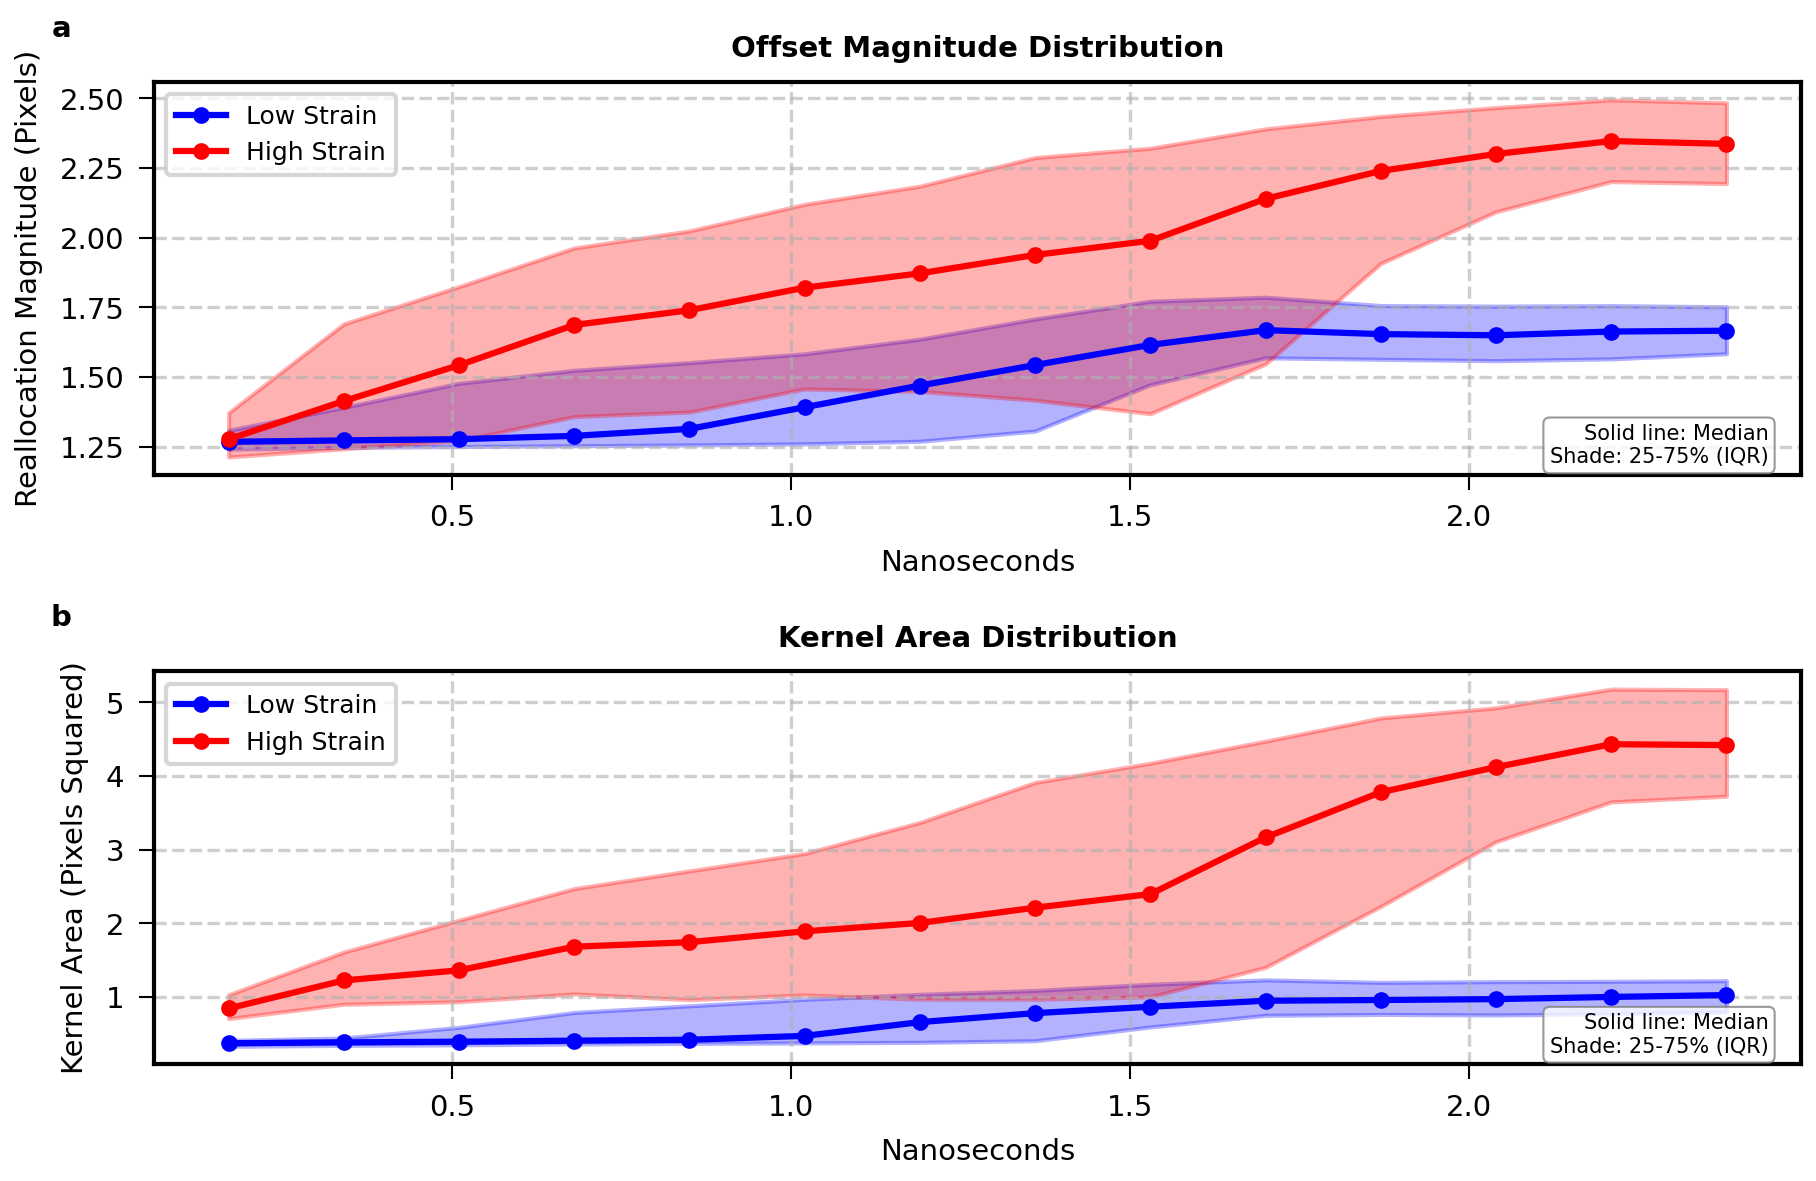

In [22]:
#!/usr/bin/env python3
"""
Figure 2: Panels A and B - Statistical Distributions
"""

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown, Image
import logging

logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration - EDIT THESE VALUES
# ------------------------------------------------------------------- #
OUTPUT_DIR = "em_combined_vis_from_notebook"
SPLIT_METRIC = "strain"  # 'strain' or 'hotspot'
SAMPLE_ID = 16

# ------------------------------------------------------------------- #
# Check DataFrame
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Please run the data loading cell (Cell 1) first.")

def set_publication_style():
    plt.rcParams.update({
        'font.family': 'sans-serif', 'font.sans-serif': 'Arial',
        'font.size': 7, 'axes.labelsize': 7,
        'xtick.labelsize': 7, 'ytick.labelsize': 7,
        'legend.fontsize': 6, 'figure.dpi': 300
    })

def generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, output_path):
    set_publication_style()
    
    fig_width_mm = 180
    fig_width_in = fig_width_mm / 25.4
    fig_height_in = fig_width_in * 0.6  # Increased from 0.4 for larger plots
    
    fig = plt.figure(figsize=(fig_width_in, fig_height_in))
    gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.5)  # Increased from 0.35 for more separation
    
    label_props = dict(fontsize=7, fontweight='bold', va='bottom', ha='right')
    quantiles_to_plot = [25, 50, 75]

    # Panel A: Offset Magnitude (was Panel E)
    ax_graph_a = fig.add_subplot(gs[0, 0])
    ax_graph_a.text(-0.05, 1.1, 'a', transform=ax_graph_a.transAxes, **label_props)
    ax_graph_a.set_title("Offset Magnitude Distribution", fontsize=7, weight='bold')
    ts_data_mag = sorted(stats_data_mag.keys())
    if ts_data_mag:
        # MODIFIED: Convert integer timesteps to nanoseconds for the x-axis
        x_int = np.array(ts_data_mag)
        min_ts = x_int.min()
        x = 0.17 + (x_int - min_ts) * 0.17
        
        color_map_cats = {"low": "blue", "high": "red", "hotspot": "red", "non_hotspot": "blue"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_mag[t] for t in ts_data_mag): continue
            quantiles = {f'q{q}': np.array([stats_data_mag[t].get(f"{cat_key}_q{q}", np.nan) 
                                            for t in ts_data_mag]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_a.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                            marker='o', markersize=3)
            ax_graph_a.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_a.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                    transform=ax_graph_a.transAxes, fontsize=5, verticalalignment='bottom', 
                    horizontalalignment='right', 
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))
    
    # MODIFIED: Updated x-axis label
    ax_graph_a.set_xlabel("Nanoseconds")
    ax_graph_a.set_ylabel("Reallocation Magnitude (Pixels)")
    ax_graph_a.legend(loc='best')
    ax_graph_a.grid(True, linestyle='--', alpha=0.6)

    # Panel B: Kernel Area (was Panel F)
    ax_graph_b = fig.add_subplot(gs[1, 0])
    ax_graph_b.text(-0.05, 1.1, 'b', transform=ax_graph_b.transAxes, **label_props)
    ax_graph_b.set_title("Kernel Area Distribution", fontsize=7, weight='bold')
    ts_data_area = sorted(stats_data_area.keys())
    if ts_data_area:
        # MODIFIED: Convert integer timesteps to nanoseconds for the x-axis
        x_int = np.array(ts_data_area)
        min_ts = x_int.min()
        x = 0.17 + (x_int - min_ts) * 0.17
        
        color_map_cats = {"low": "blue", "high": "red", "hotspot": "red", "non_hotspot": "blue"}
        for cat_key, label in graph_labels.items():
            if not any(f"{cat_key}_q50" in stats_data_area[t] for t in ts_data_area): continue
            quantiles = {f'q{q}': np.array([stats_data_area[t].get(f"{cat_key}_q{q}", np.nan) 
                                            for t in ts_data_area]) for q in quantiles_to_plot}
            color = color_map_cats.get(cat_key, 'black')
            ax_graph_b.plot(x, quantiles['q50'], color=color, lw=1.5, label=label, 
                            marker='o', markersize=3)
            ax_graph_b.fill_between(x, quantiles['q25'], quantiles['q75'], color=color, alpha=0.3)
    ax_graph_b.text(0.98, 0.02, "Solid line: Median\nShade: 25-75% (IQR)", 
                    transform=ax_graph_b.transAxes, fontsize=5, verticalalignment='bottom', 
                    horizontalalignment='right', 
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=0.5, alpha=0.8))

    # MODIFIED: Updated x-axis label
    ax_graph_b.set_xlabel("Nanoseconds")
    ax_graph_b.set_ylabel("Kernel Area (Pixels Squared)")
    ax_graph_b.legend(loc='best')
    ax_graph_b.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout(pad=0.3, h_pad=0.5, w_pad=0.5)
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
    plt.close(fig)

# --- Main Execution ---
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
QUANTILES_TO_CALCULATE = [25, 50, 75]

# Calculate statistics on GLOBAL dataframe
all_timesteps_global = sorted(df['timestep'].unique())
stats_data_mag = {}
stats_data_area = {}
logging.info(f"Calculating statistics for Panels A & B using '{SPLIT_METRIC}' metric...")

if SPLIT_METRIC == 'strain':
    graph_labels = {"low": "Low Strain", "high": "High Strain"}
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        for cat_label, data_group in ts_df_global.groupby('strain_category'):
            data_mag = data_group['deformation_magnitude']
            stats_data_mag[ts][f"{cat_label}_q25"] = np.quantile(data_mag, 0.25) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q50"] = np.quantile(data_mag, 0.50) if not data_mag.empty else np.nan
            stats_data_mag[ts][f"{cat_label}_q75"] = np.quantile(data_mag, 0.75) if not data_mag.empty else np.nan
            
            data_area = data_group['ellipse_area']
            stats_data_area[ts][f"{cat_label}_q25"] = np.quantile(data_area, 0.25) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q50"] = np.quantile(data_area, 0.50) if not data_area.empty else np.nan
            stats_data_area[ts][f"{cat_label}_q75"] = np.quantile(data_area, 0.75) if not data_area.empty else np.nan
else:  # 'hotspot'
    graph_labels = {"hotspot": "Hotspot (T≥875K)", "non_hotspot": "Non-Hotspot"}
    for ts in all_timesteps_global:
        ts_df_global = df[df['timestep'] == ts]
        if ts_df_global.empty: continue
        stats_data_mag[ts] = {}
        stats_data_area[ts] = {}
        hotspot_mask = ts_df_global['Temperature (T)'] >= 875
        data_map_mag = {
            "hotspot": ts_df_global[hotspot_mask]['deformation_magnitude'], 
            "non_hotspot": ts_df_global[~hotspot_mask]['deformation_magnitude']
        }
        data_map_area = {
            "hotspot": ts_df_global[hotspot_mask]['ellipse_area'], 
            "non_hotspot": ts_df_global[~hotspot_mask]['ellipse_area']
        }
        for cat_label in data_map_mag.keys():
            data_mag = data_map_mag[cat_label]
            data_area = data_map_area[cat_label]
            for q in QUANTILES_TO_CALCULATE:
                stats_data_mag[ts][f"{cat_label}_q{q}"] = np.quantile(data_mag, q / 100.0) if not data_mag.empty else np.nan
                stats_data_area[ts][f"{cat_label}_q{q}"] = np.quantile(data_area, q / 100.0) if not data_area.empty else np.nan

# Generate figure
layer_name = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]
out_file_pdf = Path(OUTPUT_DIR) / f"fig2_ab_{layer_name}_sample{SAMPLE_ID}_{SPLIT_METRIC}.pdf"
out_file_png = out_file_pdf.with_suffix('.png')

generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_pdf)
generate_ab_figure(stats_data_mag, stats_data_area, graph_labels, out_file_png)

display(Markdown(f"### Figure 2 (A-B) saved to: `{out_file_pdf.resolve()}`"))
display(Image(filename=out_file_png))

In [23]:
#!/usr/bin/env python3
"""
GIF: Full Field | Zoomed Crop | Kernel Offsets
One GIF per spatial location, animating across ALL timesteps in the data.

Layout per frame:
  [ Full prediction field ]  [ Zoomed crop w/ kernel dots ]  [ Kernel offset panel ]
"""

import warnings
import logging
import numpy as np
import matplotlib
matplotlib.set_loglevel("error")          # silence all matplotlib warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle, Circle
from matplotlib.animation import FuncAnimation, PillowWriter
from pathlib import Path

warnings.filterwarnings("ignore")         # suppress any remaining runtime warnings
logging.basicConfig(level=logging.INFO)

# ------------------------------------------------------------------- #
# Configuration
# ------------------------------------------------------------------- #
OUTPUT_DIR           = "em_combined_vis_from_notebook"
VISUALIZATION_METRIC = 'strain_rate_magnitude'
SPATIAL_LOCATIONS    = [45, 97, 153, 46, 209, 67]
SAMPLE_ID            = 12

# Timestep -> display label mapping (extend as needed; unmapped ones show raw value)
TIMESTEP_LABELS = {
    7:  "1.36 ns",
    10: "1.87 ns",
    13: "2.38 ns",
}

FPS      = 3      # frames per second
DPI      = 130
ZOOM_WIN = 18     # half-width of zoom crop (pixels)
CMAP     = "jet"

# ------------------------------------------------------------------- #
# Shared geometry
# ------------------------------------------------------------------- #
cmap_tab   = plt.get_cmap("tab20")
kernel_colors = [cmap_tab(i) for i in np.linspace(0, 1, 9, endpoint=False)]
grid_coords   = np.array([[-1,-1],[-1,0],[-1,1],
                            [0,-1], [0,0], [0,1],
                            [1,-1], [1,0], [1,1]], dtype=np.float32)
loc_colors    = ['#eb34b7', 'crimson', 'limegreen', '#34eb3d', 'orange', 'cyan']
ZOOM_LIM      = 3.5   # half-width of kernel panel axes


def ts_label(ts):
    return TIMESTEP_LABELS.get(ts, f"t={ts}")


def make_location_gif(loc_idx, cx, cy, all_timesteps, preds_by_ts, offsets_by_ts,
                      output_path, title_prefix, vmin, vmax, H, W):
    """One GIF for one spatial location, all timesteps."""

    loc_color = loc_colors[loc_idx % len(loc_colors)]
    num_ts    = len(all_timesteps)

    # Natural aspect ratio of field
    aspect = H / W

    # Figure width fixed; height driven by field aspect
    fig_w = 13
    fig_h = max(fig_w * aspect * 0.42, 3.8)

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=DPI, facecolor='white')
    fig.set_constrained_layout(True)
    fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.08, hspace=0, wspace=0.06)

    # Width ratios balanced: full field gets more room, zoom+kernel share the rest
    zoom_frac = (2 * ZOOM_WIN) / W
    w_zoom = max(zoom_frac * 1.6, 0.25)
    gs = gridspec.GridSpec(1, 3, figure=fig,
                           width_ratios=[1.0, w_zoom, w_zoom])

    ax_full = fig.add_subplot(gs[0])
    ax_zoom = fig.add_subplot(gs[1])
    ax_kern = fig.add_subplot(gs[2])

    # Suptitle + timestep text stacked above
    fig.suptitle(
        f"{title_prefix}  —  Loc ({cx},{cy})",
        fontsize=9, fontweight='bold', color=loc_color,
    )
    time_text = fig.text(0.5, 1.0, '', ha='center', va='bottom',
                         fontsize=10, fontweight='bold', color='black',
                         transform=fig.transFigure)

    # ============================================================
    # Panel 1: Full field
    # ============================================================
    ax_full.set_title("Full Prediction Field", fontsize=8, fontweight='bold', pad=4)
    ax_full.set_aspect('equal', adjustable='box')
    ax_full.axis('off')

    init_pred = next(iter(preds_by_ts.values()))
    im_full = ax_full.imshow(
        init_pred,
        cmap=CMAP, vmin=vmin, vmax=vmax,
        extent=[-0.5, W - 0.5, H - 0.5, -0.5],
        origin='upper', interpolation='nearest',
    )
    loc_box_full = Rectangle(
        (cx - 1.5, cy - 1.5), 3, 3,
        lw=2, ec=loc_color, fc='none', zorder=5,
    )
    ax_full.add_patch(loc_box_full)

    # Colorbar attached tightly to ax_full only
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_full)
    cax = divider.append_axes("right", size="4%", pad=0.05)
    cbar = fig.colorbar(im_full, cax=cax)
    cbar.ax.tick_params(labelsize=6)

    # ============================================================
    # Panel 2: Zoomed crop — field only, no circles
    # ============================================================
    ax_zoom.set_title("Zoomed Region", fontsize=8, fontweight='bold', pad=4)
    ax_zoom.set_aspect('equal', adjustable='box')
    ax_zoom.axis('off')

    im_zoom = ax_zoom.imshow(
        init_pred,
        cmap=CMAP, vmin=vmin, vmax=vmax,
        extent=[-0.5, W - 0.5, H - 0.5, -0.5],
        origin='upper', interpolation='nearest',
    )
    ax_zoom.set_xlim(cx - ZOOM_WIN, cx + ZOOM_WIN)
    ax_zoom.set_ylim(cy + ZOOM_WIN, cy - ZOOM_WIN)

    # Single outline box covering the full 3x3 conventional kernel footprint
    kernel_outline = Rectangle(
        (cx - 1.5, cy - 1.5), 3, 3,
        lw=1.5, ec='white', fc='none', ls='--', alpha=0.8, zorder=3,
    )
    ax_zoom.add_patch(kernel_outline)

    zoom_dynamic = []   # unused but kept for symmetry

    # ============================================================
    # Panel 3: Kernel offset panel
    # ============================================================
    ax_kern.set_title("Deformable Kernel Offsets", fontsize=8, fontweight='bold')
    ax_kern.set_aspect('equal', adjustable='box')
    ax_kern.set_xlim(-ZOOM_LIM, ZOOM_LIM)
    ax_kern.set_ylim(-ZOOM_LIM, ZOOM_LIM)
    ax_kern.axis('off')
    ax_kern.set_facecolor('white')

    # Static background grid
    grid_range = int(np.ceil(ZOOM_LIM))
    for x_g in range(-grid_range, grid_range):
        for y_g in range(-grid_range, grid_range):
            is_central = -1 <= x_g < 2 and -1 <= y_g < 2
            ax_kern.add_patch(Rectangle(
                (x_g - 0.5, y_g - 0.5), 1, 1,
                lw=0.75 if is_central else 0.4,
                ec='dimgray' if is_central else 'lightgray',
                fc='none',
                ls='-' if is_central else '--',
                alpha=0.8 if is_central else 0.5,
            ))

    # Static: conventional kernel circles (hollow)
    for i_el in range(9):
        gx, gy = grid_coords[i_el]
        ax_kern.add_patch(Circle(
            (gx, gy), radius=0.35,
            lw=1, ec=kernel_colors[i_el], fc='none',
            ls='--', alpha=0.5, zorder=3,
        ))

    kern_dynamic = []   # cleared each frame



    # ============================================================
    # Update function
    # ============================================================
    def update(frame_idx):
        ts    = all_timesteps[frame_idx]
        label = TIMESTEP_LABELS.get(ts, str(ts))
        time_text.set_text(f"t = {label}  (frame {frame_idx+1}/{num_ts})")

        pred = preds_by_ts.get(ts)
        if pred is None:
            return []

        # Update heatmaps
        im_full.set_data(pred)
        im_zoom.set_data(pred)

        # Clear previous kernel dynamic artists only
        for a in kern_dynamic:
            try: a.remove()
            except: pass
        kern_dynamic.clear()

        offsets = offsets_by_ts.get(ts, {}).get((cy, cx), np.zeros((9, 2)))

        for i_el in range(9):
            gx, gy  = grid_coords[i_el]
            dy_off  = offsets[i_el, 0]
            dx_off  = offsets[i_el, 1]
            kc      = kernel_colors[i_el]

            # Kernel panel: arrow from stationary to deformed position
            start      = grid_coords[i_el]
            offset_vec = np.array([dx_off, -dy_off])   # flip y for display coords
            end_kern   = start + offset_vec

            if np.linalg.norm(offset_vec) > 0.05:
                arr = ax_kern.annotate(
                    '', xy=(end_kern[0], end_kern[1]),
                    xytext=(start[0], start[1]),
                    arrowprops=dict(arrowstyle='->', color=kc, lw=1.4, mutation_scale=10),
                    zorder=6,
                )
                kern_dynamic.append(arr)

            circ = Circle(
                (end_kern[0], end_kern[1]), radius=0.38,
                lw=0.6, ec='black', fc=kc, alpha=0.9, zorder=7,
            )
            ax_kern.add_patch(circ)
            kern_dynamic.append(circ)

        return [im_full, im_zoom, time_text]

    ani = FuncAnimation(
        fig, update, frames=num_ts,
        interval=int(1000 / FPS), blit=False, repeat=True,
    )

    writer = PillowWriter(fps=FPS)
    ani.save(str(output_path), writer=writer,
             savefig_kwargs={'facecolor': 'white'})
    plt.close(fig)
    logging.info(f"  Saved → {output_path.name}")


# ------------------------------------------------------------------- #
# Main
# ------------------------------------------------------------------- #
if 'df' not in globals() or df is None:
    raise NameError("DataFrame 'df' not found. Run the data loading cell first.")
if 'CSV_PATH' not in globals():
    raise NameError("Variable 'CSV_PATH' not found.")

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
spatial_locs  = list(zip(SPATIAL_LOCATIONS[::2], SPATIAL_LOCATIONS[1::2]))
sample_df     = df[df['sample_id'] == SAMPLE_ID].copy()

if sample_df.empty:
    logging.error(f"No data for sample_id {SAMPLE_ID}.")
else:
    all_timesteps = sorted(sample_df['timestep'].unique())
    logging.info(f"Found {len(all_timesteps)} timesteps: {all_timesteps}")

    # Build preds and offsets for every timestep
    preds_by_ts   = {}
    offsets_by_ts = {}
    offset_cols   = [f'offset_k{i}_d{ax}' for i in range(9) for ax in ['y', 'x']]

    for ts in all_timesteps:
        ts_df = sample_df[sample_df['timestep'] == ts]
        if ts_df.empty:
            continue
        preds_by_ts[ts] = ts_df.pivot_table(
            index='pixel_y', columns='pixel_x', values=VISUALIZATION_METRIC
        ).values

        loc_df = ts_df.set_index(['pixel_y', 'pixel_x'])
        offsets_by_ts[ts] = {}
        for x, y in spatial_locs:
            if (y, x) in loc_df.index:
                flat = loc_df.loc[(y, x), offset_cols].values
                offsets_by_ts[ts][(y, x)] = np.stack([flat[::2], flat[1::2]], axis=-1)

    H, W   = next(iter(preds_by_ts.values())).shape
    vmin   = min(v.min() for v in preds_by_ts.values())
    vmax   = max(v.max() for v in preds_by_ts.values())

    layer_name   = Path(CSV_PATH).stem.split('_unified_data')[0].split('_')[-1]
    clean_metric = VISUALIZATION_METRIC.replace(" ", "_")
    title_prefix = ("Strain Rate Magnitude" if VISUALIZATION_METRIC == 'strain_rate_magnitude'
                    else VISUALIZATION_METRIC.replace("_", " ").title())

    for loc_idx, (cx, cy) in enumerate(spatial_locs):
        gif_path = (Path(OUTPUT_DIR) /
                    f"anim_{layer_name}_s{SAMPLE_ID}_loc{cx}_{cy}_{clean_metric}.gif")
        logging.info(f"Generating GIF for loc ({cx},{cy}) ...")
        make_location_gif(
            loc_idx, cx, cy,
            all_timesteps, preds_by_ts, offsets_by_ts,
            gif_path, title_prefix, vmin, vmax, H, W,
        )

    print(f"\n✓ {len(spatial_locs)} GIFs saved to {OUTPUT_DIR}/")
    print("  One GIF per spatial location, all timesteps.")


✓ 3 GIFs saved to em_combined_vis_from_notebook/
  One GIF per spatial location, all timesteps.
